In [ ]:
!pip install torch transformers opendatasets --quiet

In [ ]:
# !pip install datasets --upgrade --quiet

In [ ]:
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

print(f"GPU memory before: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

GPU memory before: 1.91 GB


In [ ]:
import os
import opendatasets as od
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import numpy as np
import pandas as pd
import ast
import re
import torch
from transformers import AutoTokenizer
import random


In [ ]:
od.download("https://www.kaggle.com/datasets/thedevastator/dailydialog-unlock-the-conversation-potential-in")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: tulikasharma
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/thedevastator/dailydialog-unlock-the-conversation-potential-in


100%|██████████| 2.46M/2.46M [00:00<00:00, 453MB/s]

In [ ]:

# from huggingface_hub import login
# from google.colab import userdata

# login(token=userdata.get('HF_TOKEN'))

In [ ]:
# ---------- Config ----------
DATA_DIR = "/content/dailydialog-unlock-the-conversation-potential-in"
BATCH_SIZE = 32
K_CONTEXT = 4
TOKENIZER_NAME = "bert-base-uncased"


PAD_EMOTION_ID = -100

In [ ]:
def parse_dialog_field(s):
    # Remove outer brackets and split by "' '"
    s = s.strip()
    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1].strip()
    # split on ' ' between quotes
    parts = re.split(r"'\s*'\s*", s)
    # clean quotes and whitespace
    parts = [p.strip().strip("'\"") for p in parts if p.strip()]
    return parts

In [ ]:
def parse_emotion_field(s):
    s = s.strip()
    # remove brackets
    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1].strip()

    # replace commas with spaces and split
    parts = s.replace(",", " ").split()
    nums = []
    for x in parts:
        try:
            nums.append(int(x))
        except ValueError:
            continue
    return nums


In [ ]:
def fix_list_format(s):
    """Fix malformed list strings like '[3 4 12 0]' → [3, 4, 12, 0] and return as list of ints."""
    if not isinstance(s, str):
        return s
    s = s.strip()

    # Handle edge case
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return val
    except Exception:
        pass


    if s.startswith("[") and s.endswith("]"):
        inner = s[1:-1].strip()

        inner = re.sub(r"\s+", ",", inner)
        fixed = f"[{inner}]"
        try:
            val = ast.literal_eval(fixed)
            if isinstance(val, list):
                return val
        except Exception:
            return None
    return None

In [ ]:
def load_and_clean_split(data_dir, split):
    file_path = f"{data_dir}/{split}.csv"
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing file: {file_path}")


    try:
        df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        df = pd.DataFrame()

    # print(f"\n[DEBUG] Reading {file_path}")
    # print(f"  Rows read: {len(df)}")
    # print(f"  Columns detected: {df.columns.tolist()}")

    # print(df.head(2))
    print(f"Loaded {file_path} with {len(df)} rows.")

    cleaned = []
    dropped_examples = 0

    for idx, row in df.iterrows():
        raw_dialog = row.get("dialog", "")
        raw_emotion = row.get("emotion", "")

        # parse dialog and emotion
        parsed_dialog = parse_dialog_field(raw_dialog)
        parsed_emotion = parse_emotion_field(raw_emotion)


        if not isinstance(parsed_dialog, list) or not isinstance(parsed_emotion, list):
            dropped_examples += 1
            continue

        # truncate to the minimum length
        min_len = min(len(parsed_dialog), len(parsed_emotion))
        if min_len == 0:
            dropped_examples += 1
            continue

        parsed_dialog = parsed_dialog[:min_len]
        parsed_emotion = parsed_emotion[:min_len]


        clean_row = {
            "dialog": parsed_dialog,
            "act": row.get("act", None),
            "emotion": parsed_emotion
        }
        cleaned.append(clean_row)

    print(f"Kept {len(cleaned)} valid dialogues out of {len(df)} in split '{split}'. Dropped {dropped_examples}.")
    if len(cleaned) == 0:
        return pd.DataFrame()
    return pd.DataFrame(cleaned)


In [ ]:
# df = load_and_clean_split(DATA_DIR, "train")
# print(df.head(3))


# for i, emo_list in enumerate(df["emotion"].head(5)):
#     print(f"Dialog {i} emotion list:", emo_list)


Loaded /content/dailydialog-unlock-the-conversation-potential-in/train.csv with 11118 rows.
Kept 11118 valid dialogues out of 11118 in split 'train'. Dropped 0.
                                              dialog                    act  \
0  [Say , Jim , how about going for a few beers a...  [3 4 2 2 2 3 4 1 3 4]   
1  [Can you do push-ups ? '\n " Of course I can ....          [2 1 2 2 1 1]   
2  [Can you study with the radio on ?, No , I lis...            [2 1 2 1 1]   

        emotion  
0     [0, 0, 0]  
1        [0, 0]  
2  [0, 0, 0, 0]  
Dialog 0 emotion list: [0, 0, 0]
Dialog 1 emotion list: [0, 0]
Dialog 2 emotion list: [0, 0, 0, 0]
Dialog 3 emotion list: [0, 0]
Dialog 4 emotion list: [0, 0, 0, 0, 0, 6, 0, 6, 0]


In [ ]:
# import pandas as pd
# pd.read_csv("/content/dailydialog-unlock-the-conversation-potential-in/train.csv").head(2)


In [ ]:
class DailyDialogLocalDataset(Dataset):
    def __init__(self, data_dir, split="train", k_context=4):
        self.data_path = os.path.join(data_dir, f"{split}.csv")
        if not os.path.exists(self.data_path):
            raise FileNotFoundError(f"File not found: {self.data_path}")

        self.data = load_and_clean_split(data_dir, split)
        print(f"Loaded {split} split: {len(self.data)} dialogues from {self.data_path}")

        required_cols = {'dialog', 'act', 'emotion'}
        if not required_cols.issubset(self.data.columns):
            raise ValueError(f"Missing required columns in CSV. Found: {self.data.columns}")

        self.examples = []
        valid_dialogs = 0

        for dialog_id, row in self.data.iterrows():
            utterances = row['dialog']
            emotions = row['emotion']

            if not isinstance(utterances, list) or not isinstance(emotions, list):
                continue

            min_len = min(len(utterances), len(emotions))
            if min_len == 0:
                continue

            utterances = utterances[:min_len]
            emotions = [int(e) for e in emotions[:min_len]]
            valid_dialogs += 1


            turns = []
            for i in range(min_len):
                speaker = 'A' if i % 2 == 0 else 'B'
                turns.append({
                    'speaker': speaker,
                    'text': utterances[i],
                    'emotion_id': emotions[i],
                    'turn_idx': i
                })

            # Track last emotion by speaker for shift calculation
            last_emotion_by_speaker = {'A': None, 'B': None}

            # Process each turn
            for i, turn in enumerate(turns):
                speaker = turn['speaker']
                current_emotion = turn['emotion_id']

                # Check if this speaker has spoken before
                has_prev = last_emotion_by_speaker[speaker] is not None

                # Calculate shift label
                if has_prev:
                    prev_emotion = last_emotion_by_speaker[speaker]
                    shift_label = int(current_emotion != prev_emotion)
                    prev_emotion_id = prev_emotion
                else:
                    # First time this speaker speaks - no shift calculation possible
                    shift_label = -100
                    prev_emotion_id = -100

                # Update last emotion for the speaker
                last_emotion_by_speaker[speaker] = current_emotion

                # Build context (last k_context turns before current turn)
                context_start = max(0, i - k_context)
                context_turns = turns[context_start:i]

                # Pad context to k_context length from the left
                while len(context_turns) < k_context:
                    context_turns = [{
                        'speaker': 'PAD',
                        'text': '',
                        'emotion_id': -100,
                        'turn_idx': -1
                    }] + context_turns

                self.examples.append({
                    "dialog_id": dialog_id,
                    "turn_idx": i,
                    "context": context_turns,
                    "current_turn": turn,
                    "has_prev": has_prev,
                    "prev_emotion_id": prev_emotion_id,
                    "shift_label": shift_label
                })

        print(f"Kept {valid_dialogs} valid dialogues out of {len(self.data)} in split '{split}'.")
        print(f"Total examples (turns): {len(self.examples)}")

        if len(self.examples) == 0:
            raise ValueError("No valid dialogues found after parsing.")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]

In [ ]:

def collate_fn(batch, tokenizer, max_context_len=512, max_current_len=128):

    contexts = [item['context'] for item in batch]
    current_turns = [item['current_turn'] for item in batch]
    shift_labels = [item['shift_label'] for item in batch]
    has_prev_flags = [item['has_prev'] for item in batch]
    prev_emotion_ids = [item['prev_emotion_id'] for item in batch]
    emotion_ids = [turn['emotion_id'] for turn in current_turns]

    # build context strings (join speaker: text)
    sep = tokenizer.sep_token if tokenizer.sep_token else "[SEP]"
    context_strings = []
    for ctx in contexts:
        # ctx is length k_context
        parts = []
        for turn in ctx:
            if turn["speaker"] == "PAD":
                parts.append("")
            else:
                parts.append(f"{turn['speaker']}: {turn['text']}")
        context_strings.append(f" {sep} ".join(parts))

    current_strings = [f"{turn['speaker']}: {turn['text']}" if turn['speaker'] != "PAD" else "" for turn in current_turns]

    ctx_enc = tokenizer(
        context_strings,
        padding=True,
        truncation=True,
        max_length=max_context_len,
        return_tensors="pt"
    )
    cur_enc = tokenizer(
        current_strings,
        padding=True,
        truncation=True,
        max_length=max_current_len,
        return_tensors="pt"
    )

    return {
        'context_input_ids': ctx_enc['input_ids'],
        'context_attention_mask': ctx_enc['attention_mask'],
        'current_input_ids': cur_enc['input_ids'],
        'current_attention_mask': cur_enc['attention_mask'],
        'shift_labels': torch.tensor(shift_labels, dtype=torch.long),
        'emotion_labels': torch.tensor(emotion_ids, dtype=torch.long),
        'has_prev_mask': torch.tensor(has_prev_flags, dtype=torch.bool),
        'prev_emotion_ids': torch.tensor(prev_emotion_ids, dtype=torch.long),
        'dialog_ids': [item['dialog_id'] for item in batch],
        'turn_indices': [item['turn_idx'] for item in batch]
    }


In [ ]:

def calculate_class_weights(dataset):
    labels = [int(item['shift_label']) for item in dataset if item['has_prev'] and item['shift_label'] != PAD_EMOTION_ID]
    if len(labels) == 0:
        return torch.tensor([1.0, 1.0], dtype=torch.float)
    labels = np.array(labels, dtype=np.int64)
    counts = np.bincount(labels, minlength=2)
    counts = np.where(counts == 0, 1, counts)
    total = labels.shape[0]
    weights = total / (2.0 * counts)
    return torch.tensor(weights, dtype=torch.float)

In [ ]:
# ---------- Main ----------
if __name__ == "__main__":
    # tokenizer
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
    if tokenizer.sep_token is None:
        tokenizer.add_special_tokens({'additional_special_tokens': ['[SEP]']})

    # instantiate datasets (correct signature: data_dir, split, k_context)
    train_dataset = DailyDialogLocalDataset(DATA_DIR, split="train", k_context=K_CONTEXT)
    valid_dataset = DailyDialogLocalDataset(DATA_DIR, split="validation", k_context=K_CONTEXT)
    test_dataset  = DailyDialogLocalDataset(DATA_DIR, split="test", k_context=K_CONTEXT)

    print("Datasets instantiated.")
    print(f"Train examples: {len(train_dataset)} | Val examples: {len(valid_dataset)} | Test examples: {len(test_dataset)}")

    # compute class weights
    cw = calculate_class_weights(train_dataset)
    print("Class weights (no-shift, shift):", cw.tolist())

    # build dataloaders using lambda to pass tokenizer into collate_fn
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda x: collate_fn(x, tokenizer))
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda x: collate_fn(x, tokenizer))
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda x: collate_fn(x, tokenizer))

    # group examples by dialog_id for better visualization

    dialog_map = defaultdict(list)
    for ex in train_dataset.examples:
        dialog_map[ex["dialog_id"]].append(ex)

    # randomly pick 3 dialogs to visualize
    sample_dialogs = random.sample(list(dialog_map.keys()), 3)

    for d_id in sample_dialogs:
        turns = dialog_map[d_id]
        print(f"\n=== Dialog {d_id} ({len(turns)} turns) ===")
        for ex in turns:
            if not ex["has_prev"]:
                continue
            prev_e = ex["prev_emotion_id"]
            curr_e = ex["current_turn"]["emotion_id"]
            shift = ex["shift_label"]
            print(f"Turn {ex['turn_idx']:>2} | prev={prev_e} → curr={curr_e} | shift={shift}")
            print("   Context:")
            for c in ex["context"]:
                print("    ", f"{c['speaker']}: {c['text'][:70]} (emo={c['emotion_id']})")
            print("   → CUR:", f"{ex['current_turn']['speaker']}: {ex['current_turn']['text'][:70]} (emo={curr_e})")
            print("-" * 70)

    # test one batch
    batch = next(iter(train_loader))
    print("\nBatch tensor shapes:")
    print("context_input_ids:", batch['context_input_ids'].shape)
    print("current_input_ids:", batch['current_input_ids'].shape)
    print("shift_labels:", batch['shift_labels'].shape)
    print("has_prev_mask:", batch['has_prev_mask'].shape)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Loaded /content/dailydialog-unlock-the-conversation-potential-in/train.csv with 11118 rows.
Kept 11118 valid dialogues out of 11118 in split 'train'. Dropped 0.
Loaded train split: 11118 dialogues from /content/dailydialog-unlock-the-conversation-potential-in/train.csv
Kept 11118 valid dialogues out of 11118 in split 'train'.
Total examples (turns): 53096
Loaded /content/dailydialog-unlock-the-conversation-potential-in/validation.csv with 1000 rows.
Kept 1000 valid dialogues out of 1000 in split 'validation'. Dropped 0.
Loaded validation split: 1000 dialogues from /content/dailydialog-unlock-the-conversation-potential-in/validation.csv
Kept 1000 valid dialogues out of 1000 in split 'validation'.
Total examples (turns): 4952
Loaded /content/dailydialog-unlock-the-conversation-potential-in/test.csv with 1000 rows.
Kept 1000 valid dialogues out of 1000 in split 'test'. Dropped 0.
Loaded test split: 1000 dialogues from /content/dailydialog-unlock-the-conversation-potential-in/test.csv
Kept

In [ ]:
# import pandas as pd

# path = f"{DATA_DIR}/train.csv"
# df = pd.read_csv(path)

# print("Raw dialog field (first 300 chars):")
# print(df.loc[0, "dialog"][:300])
# print("\n---\nRaw emotion field:")
# print(df.loc[0, "emotion"])


In [ ]:
# import numpy as np

# emotions_flat = [ex["current_turn"]["emotion_id"] for ex in train_dataset.examples]
# unique, counts = np.unique(emotions_flat, return_counts=True)
# print(dict(zip(unique, counts)))

In [ ]:
# shifts = [ex["shift_label"] for ex in train_dataset.examples if ex["shift_label"] != -100]
# unique, counts = np.unique(shifts, return_counts=True)
# print("Shift label distribution:", dict(zip(unique, counts)))


In [ ]:
# import ast

# path = f"{DATA_DIR}/train.csv"
# df = pd.read_csv(path)

# def fix_list_format(s):
#     if isinstance(s, str):
#         s = s.strip().replace("[ ", "[").replace(" ]", "]").replace("  ", " ").replace(" ", ", ")
#     return s

# df["dialog"] = df["dialog"].apply(lambda x: ast.literal_eval(fix_list_format(x)))
# df["act"] = df["act"].apply(lambda x: ast.literal_eval(fix_list_format(x)))
# df["emotion"] = df["emotion"].apply(lambda x: ast.literal_eval(fix_list_format(x)))

# length_mismatch = df[
#     (df["dialog"].str.len() != df["act"].str.len()) |
#     (df["dialog"].str.len() != df["emotion"].str.len())
# ]

# print(f"Total rows: {len(df)}")
# print(f"Rows with mismatch: {len(length_mismatch)}")
# print(length_mismatch.head(3))


In [ ]:
# import pandas as pd

# path = f"{DATA_DIR}/train.csv"
# df = pd.read_csv(path)

# # Test first 10 emotion entries
# for i in range(10):
#     raw = df.loc[i, "emotion"]
#     fixed = fix_list_format(raw)
#     print(f"Row {i}:")
#     print("  raw  =", raw)
#     print("  fixed=", fixed)
#     print()


In [ ]:

print("\n=== Testing corrected shift logic ===")
for dialog_id in [0, 1, 2]:
    dialog_turns = [ex for ex in train_dataset.examples if ex['dialog_id'] == dialog_id]
    print(f"\nDialog {dialog_id}:")
    for turn in dialog_turns:
        curr = turn['current_turn']
        print(f"Turn {turn['turn_idx']}: Speaker {curr['speaker']}, Emotion {curr['emotion_id']}, "
              f"HasPrev {turn['has_prev']}, PrevEmo {turn['prev_emotion_id']}, Shift {turn['shift_label']}")


=== Testing corrected shift logic ===

Dialog 0:
Turn 0: Speaker A, Emotion 0, HasPrev False, PrevEmo -100, Shift -100
Turn 1: Speaker B, Emotion 0, HasPrev False, PrevEmo -100, Shift -100
Turn 2: Speaker A, Emotion 0, HasPrev True, PrevEmo 0, Shift 0

Dialog 1:
Turn 0: Speaker A, Emotion 0, HasPrev False, PrevEmo -100, Shift -100
Turn 1: Speaker B, Emotion 0, HasPrev False, PrevEmo -100, Shift -100

Dialog 2:
Turn 0: Speaker A, Emotion 0, HasPrev False, PrevEmo -100, Shift -100
Turn 1: Speaker B, Emotion 0, HasPrev False, PrevEmo -100, Shift -100
Turn 2: Speaker A, Emotion 0, HasPrev True, PrevEmo 0, Shift 0
Turn 3: Speaker B, Emotion 0, HasPrev True, PrevEmo 0, Shift 0


In [ ]:
!pip install scikit-learn seaborn tqdm --quiet

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from transformers import RobertaModel, RobertaTokenizer
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve, auc, classification_report
from collections import defaultdict
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

## Saves and loads experiment results and models to Google Drive

In [ ]:
import pickle
import pandas as pd
import torch
import os
from datetime import datetime
from google.colab import drive

class ColabExperimentSaver:
    """Saves and loads experiment results and models to Google Drive"""

    def __init__(self, base_dir="emotion_experiments", mount_drive=True):

        if mount_drive:
            drive.mount('/content/drive')
            self.base_path = f"/content/drive/MyDrive/{base_dir}"
        else:
            self.base_path = f"/content/{base_dir}"


        self.results_dir = os.path.join(self.base_path, "results")
        self.models_dir = os.path.join(self.base_path, "models")
        self.tables_dir = os.path.join(self.base_path, "tables")

        for dir_path in [self.results_dir, self.models_dir, self.tables_dir]:
            os.makedirs(dir_path, exist_ok=True)

        self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        print(f"Experiment saver initialized at: {self.base_path}")

    def save_baseline_experiments(self, analyzer, b0_baseline=None):
        """Save baseline experiments (B0, B1, B2)"""
        print(" Saving baseline experiments...")


        analyzer_path = os.path.join(self.results_dir, f"baseline_analyzer_{self.timestamp}.pkl")
        with open(analyzer_path, 'wb') as f:
            pickle.dump(analyzer, f)


        if b0_baseline:
            b0_path = os.path.join(self.models_dir, f"b0_baseline_{self.timestamp}.pkl")
            with open(b0_path, 'wb') as f:
                pickle.dump(b0_baseline, f)

        # Save results table
        table = analyzer.create_ablation_table()
        table_path = os.path.join(self.tables_dir, f"baseline_results_{self.timestamp}.csv")
        table.to_csv(table_path, index=False)

        print(f" Baseline analyzer saved to: {analyzer_path}")
        print(f" Baseline results table saved to: {table_path}")
        if b0_baseline:
            print(f" B0 baseline saved to: {b0_path}")

        return analyzer_path

    def save_memory_experiments(self, analyzer, model_instances=None):
        """Save memory experiments (B3 models)"""
        print(" Saving memory experiments...")


        analyzer_path = os.path.join(self.results_dir, f"memory_analyzer_{self.timestamp}.pkl")
        with open(analyzer_path, 'wb') as f:
            pickle.dump(analyzer, f)


        saved_models = {}
        if model_instances:
            for model_name, model in model_instances.items():
                model_path = os.path.join(self.models_dir, f"{model_name}_weights_{self.timestamp}.pth")
                torch.save(model.state_dict(), model_path)
                saved_models[model_name] = model_path


        if hasattr(analyzer, 'create_comprehensive_ablation_table'):
            table = analyzer.create_comprehensive_ablation_table()
        else:
            table = analyzer.create_ablation_table()

        table_path = os.path.join(self.tables_dir, f"memory_results_{self.timestamp}.csv")
        table.to_csv(table_path, index=False)

        print(f" Memory analyzer saved to: {analyzer_path}")
        print(f" Memory results table saved to: {table_path}")
        for model_name, path in saved_models.items():
            print(f" {model_name} weights saved to: {path}")

        return analyzer_path, saved_models

    def save_training_checkpoint(self, model, optimizer, epoch, loss, model_name):
        """Save training checkpoint for resuming"""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S")
        }

        checkpoint_path = os.path.join(self.models_dir, f"{model_name}_checkpoint_epoch{epoch}.pth")
        torch.save(checkpoint, checkpoint_path)
        print(f"Checkpoint saved for {model_name} at epoch {epoch}")
        return checkpoint_path

    def load_baseline_experiments(self, timestamp=None):
        """Load baseline experiments"""
        if timestamp is None:

            baseline_files = [f for f in os.listdir(self.results_dir) if f.startswith("baseline_analyzer")]
            if not baseline_files:
                raise FileNotFoundError("No baseline experiments found")
            timestamp = sorted(baseline_files)[-1].split('_')[-1].replace('.pkl', '')

        analyzer_path = os.path.join(self.results_dir, f"baseline_analyzer_{timestamp}.pkl")
        with open(analyzer_path, 'rb') as f:
            analyzer = pickle.load(f)

        # Try to load B0 baseline
        b0_path = os.path.join(self.models_dir, f"b0_baseline_{timestamp}.pkl")
        b0_baseline = None
        if os.path.exists(b0_path):
            with open(b0_path, 'rb') as f:
                b0_baseline = pickle.load(f)

        print(f"Loaded baseline experiments from timestamp: {timestamp}")
        return analyzer, b0_baseline

    def load_memory_experiments(self, timestamp=None):
        """Load memory experiments"""
        if timestamp is None:
            # Find the latest memory file
            memory_files = [f for f in os.listdir(self.results_dir) if f.startswith("memory_analyzer")]
            if not memory_files:
                raise FileNotFoundError("No memory experiments found")
            timestamp = sorted(memory_files)[-1].split('_')[-1].replace('.pkl', '')

        analyzer_path = os.path.join(self.results_dir, f"memory_analyzer_{timestamp}.pkl")
        with open(analyzer_path, 'rb') as f:
            analyzer = pickle.load(f)

        print(f"Loaded memory experiments from timestamp: {timestamp}")
        return analyzer

    def list_saved_experiments(self):
        """List all saved experiments"""
        print("Saved Experiments:")
        print("\nBaseline Experiments:")
        baseline_files = [f for f in os.listdir(self.results_dir) if f.startswith("baseline_analyzer")]
        for f in sorted(baseline_files):
            print(f"  - {f}")

        print("\nMemory Experiments:")
        memory_files = [f for f in os.listdir(self.results_dir) if f.startswith("memory_analyzer")]
        for f in sorted(memory_files):
            print(f"  - {f}")

        print(f"\nTotal: {len(baseline_files)} baseline, {len(memory_files)} memory experiments")



# ==================== MODEL DEFINITIONS ====================

In [ ]:
class BaseRobertaEmotionShift(nn.Module):
    """Base model with emotion and shift prediction heads"""
    def __init__(self, num_emotions=7, lambda_shift=0.5, tokenizer=None):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')

        if tokenizer is not None:
            self.roberta.resize_token_embeddings(len(tokenizer))

        self.emotion_head = nn.Linear(768, num_emotions)
        self.shift_head = nn.Linear(768, 1)
        self.lambda_shift = lambda_shift
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_ids, attention_mask, emotion_labels=None, shift_labels=None, has_prev_mask=None, **kwargs):
        # **kwargs accepts and ignores extra arguments like prev_emotion_ids, dialog_ids, etc.
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)

        emotion_logits = self.emotion_head(pooled_output)
        shift_logits = self.shift_head(pooled_output).squeeze(-1)

        loss = 0
        if emotion_labels is not None:
            loss_emotion = nn.CrossEntropyLoss()(emotion_logits, emotion_labels)
            loss += loss_emotion

        if shift_labels is not None and has_prev_mask is not None:
            # Only compute shift loss for turns with previous emotion
            valid_shift_mask = has_prev_mask & (shift_labels != -100)
            if valid_shift_mask.any():
                shift_loss = nn.BCEWithLogitsLoss()(
                    shift_logits[valid_shift_mask],
                    shift_labels[valid_shift_mask].float()
                )
                loss += self.lambda_shift * shift_loss

        return {
            'emotion_logits': emotion_logits,
            'shift_logits': shift_logits,
            'loss': loss
        }

In [ ]:
class B0MajorityBaseline:
    """Majority class and last-emotion heuristic baseline"""
    def __init__(self):
        self.majority_emotion = None
        self.emotion_counts = None

    def fit(self, train_dataset):
        # Calculate majority emotion
        all_emotions = []
        for item in train_dataset:
            if item['current_turn']['emotion_id'] != -100:
                all_emotions.append(item['current_turn']['emotion_id'])

        self.emotion_counts = np.bincount(all_emotions)
        self.majority_emotion = np.argmax(self.emotion_counts)

    def predict(self, batch):
        batch_size = len(batch['emotion_labels'])

        # Predict majority emotion for all
        emotion_preds = torch.full((batch_size,), self.majority_emotion, dtype=torch.long)

        # For shift: predict 0 (no shift) always, or use last-emotion heuristic
        shift_preds = torch.zeros(batch_size)

        return {
            'emotion_preds': emotion_preds,
            'shift_preds': shift_preds
        }

In [ ]:
class B1UtteranceOnlyModel(BaseRobertaEmotionShift):
    """B1: Single utterance model (no context)"""
    def __init__(self, num_emotions=7, lambda_shift=0.5, tokenizer=None):
        super().__init__(num_emotions, lambda_shift, tokenizer)

    def forward(self, current_input_ids, current_attention_mask, **kwargs):
        # Only use current utterance, ignore context
        return super().forward(current_input_ids, current_attention_mask, **kwargs)

In [ ]:
class B2ContextualModel(BaseRobertaEmotionShift):
    """B2: Contextual model with speaker tags"""
    def __init__(self, num_emotions=7, lambda_shift=0.5, tokenizer=None):
        super().__init__(num_emotions, lambda_shift, tokenizer)

    def forward(self, context_input_ids, context_attention_mask, **kwargs):
        # Use context as input (it already includes speaker tags)
        return super().forward(context_input_ids, context_attention_mask, **kwargs)

# ==================== TRAINING AND EVALUATION ====================

In [ ]:

class ExperimentRunner:
    def __init__(self, model, train_loader, val_loader, test_loader, device):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    def train_epoch(self):
        self.model.train()
        total_loss = 0

        for batch in tqdm(self.train_loader, desc="Training"):
            # Move only tensor items to device
            tensor_batch = {}
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    tensor_batch[k] = v.to(self.device)
                else:
                    tensor_batch[k] = v  # Keep non-tensors on CPU

            self.optimizer.zero_grad()

            # Handle memory model reset
            if hasattr(self.model, 'reset_memory'):
                self.model.reset_memory()

            outputs = self.model(**tensor_batch)
            loss = outputs['loss']

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)

    def evaluate(self, loader, split_name="Validation"):
        self.model.eval()
        all_emotion_preds = []
        all_emotion_labels = []
        all_shift_preds = []
        all_shift_labels = []
        all_shift_probs = []
        all_has_prev = []

        with torch.no_grad():
            for batch in tqdm(loader, desc=f"Evaluating {split_name}"):
                # Move only tensor items to device
                tensor_batch = {}
                for k, v in batch.items():
                    if isinstance(v, torch.Tensor):
                        tensor_batch[k] = v.to(self.device)
                    else:
                        tensor_batch[k] = v

                if hasattr(self.model, 'reset_memory'):
                    self.model.reset_memory()

                outputs = self.model(**tensor_batch)

                # Emotion predictions
                emotion_preds = torch.argmax(outputs['emotion_logits'], dim=1)
                all_emotion_preds.extend(emotion_preds.cpu().numpy())
                all_emotion_labels.extend(batch['emotion_labels'].cpu().numpy())

                # Shift predictions
                shift_probs = torch.sigmoid(outputs['shift_logits']).cpu().numpy()
                all_shift_probs.extend(shift_probs)
                all_shift_preds.extend((shift_probs > 0.5).astype(int))
                all_shift_labels.extend(batch['shift_labels'].cpu().numpy())
                all_has_prev.extend(batch['has_prev_mask'].cpu().numpy())

        # Convert to numpy arrays
        all_emotion_preds = np.array(all_emotion_preds)
        all_emotion_labels = np.array(all_emotion_labels)
        all_shift_preds = np.array(all_shift_preds)
        all_shift_labels = np.array(all_shift_labels)
        all_shift_probs = np.array(all_shift_probs)
        all_has_prev = np.array(all_has_prev)

        # Filter shift metrics for valid examples only
        valid_shift_mask = (all_has_prev == 1) & (all_shift_labels != -100)
        valid_shift_preds = all_shift_preds[valid_shift_mask]
        valid_shift_labels = all_shift_labels[valid_shift_mask]
        valid_shift_probs = all_shift_probs[valid_shift_mask]

        # Calculate metrics
        emotion_f1 = f1_score(all_emotion_labels, all_emotion_preds, average='macro')

        if len(valid_shift_labels) > 0:
            shift_f1 = f1_score(valid_shift_labels, valid_shift_preds)
            precision, recall, _ = precision_recall_curve(valid_shift_labels, valid_shift_probs)
            shift_auprc = auc(recall, precision)
        else:
            shift_f1 = 0.0
            shift_auprc = 0.0

        return {
            'emotion_macro_f1': emotion_f1,
            'shift_f1': shift_f1,
            'shift_auprc': shift_auprc,
            'emotion_preds': all_emotion_preds,
            'emotion_labels': all_emotion_labels,
            'shift_preds': all_shift_preds,
            'shift_labels': all_shift_labels,
            'shift_probs': all_shift_probs,
            'valid_shift_mask': valid_shift_mask
        }

    def run_experiment(self, num_epochs=3, model_name="model"):
        print(f"Starting experiment for {model_name}")

        best_val_f1 = 0
        results = {
            'train_losses': [],
            'val_metrics': [],
            'test_metrics': None
        }

        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch + 1}/{num_epochs}")

            # Training
            train_loss = self.train_epoch()
            results['train_losses'].append(train_loss)
            print(f"Train Loss: {train_loss:.4f}")

            # Validation
            val_metrics = self.evaluate(self.val_loader, "Validation")
            results['val_metrics'].append(val_metrics)

            print(f"Val Emotion F1: {val_metrics['emotion_macro_f1']:.4f}")
            print(f"Val Shift F1: {val_metrics['shift_f1']:.4f}")
            print(f"Val Shift AUPRC: {val_metrics['shift_auprc']:.4f}")

            # Save best model
            current_f1 = val_metrics['emotion_macro_f1'] + val_metrics['shift_f1']
            if current_f1 > best_val_f1:
                best_val_f1 = current_f1
                torch.save(self.model.state_dict(), f"{model_name}_best.pth")

        # Final test evaluation
        self.model.load_state_dict(torch.load(f"{model_name}_best.pth"))
        test_metrics = self.evaluate(self.test_loader, "Test")
        results['test_metrics'] = test_metrics

        print(f"\nFinal Test Results for {model_name}:")
        print(f"Test Emotion F1: {test_metrics['emotion_macro_f1']:.4f}")
        print(f"Test Shift F1: {test_metrics['shift_f1']:.4f}")
        print(f"Test Shift AUPRC: {test_metrics['shift_auprc']:.4f}")

        return results

# ==================== ANALYSIS AND VISUALIZATION ====================

In [ ]:
class ExperimentAnalyzer:
    def __init__(self):
        self.results = {}

    def add_experiment(self, name, results):
        self.results[name] = results

    def create_ablation_table(self):
        """Create ablation study table"""
        rows = []
        for model_name, result in self.results.items():
            test_metrics = result['test_metrics']
            rows.append({
                'Model': model_name,
                'Emotion Macro-F1': f"{test_metrics['emotion_macro_f1']:.4f}",
                'Shift F1': f"{test_metrics['shift_f1']:.4f}",
                'Shift AUPRC': f"{test_metrics['shift_auprc']:.4f}"
            })

        return pd.DataFrame(rows)

    def plot_learning_curves(self):
        """Plot training curves for all experiments"""
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        for model_name, result in self.results.items():
            # Plot training loss
            axes[0].plot(result['train_losses'], label=model_name)
            axes[0].set_title('Training Loss')
            axes[0].set_xlabel('Epoch')
            axes[0].set_ylabel('Loss')
            axes[0].legend()

            # Plot validation F1
            val_emotion_f1 = [m['emotion_macro_f1'] for m in result['val_metrics']]
            axes[1].plot(val_emotion_f1, label=model_name)
            axes[1].set_title('Validation Emotion F1')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('Macro F1')
            axes[1].legend()

        plt.tight_layout()
        plt.show()

    def breakdown_analysis(self, dataset, model_name):
        """Analyze performance by dialogue length, turn position, speaker"""
        if model_name not in self.results:
            return

        results = self.results[model_name]['test_metrics']

        # Group by dialogue length
        dialog_lengths = defaultdict(list)
        for i, ex in enumerate(dataset.examples):
            dialog_lengths[ex['dialog_id']].append(ex)

        length_metrics = []
        for dialog_id, turns in dialog_lengths.items():
            if len(turns) == 0:
                continue

            turn_indices = [t['turn_idx'] for t in turns]
            emotion_preds = results['emotion_preds'][turn_indices]
            emotion_labels = results['emotion_labels'][turn_indices]

            if len(emotion_preds) > 0:
                f1 = f1_score(emotion_labels, emotion_preds, average='macro')
                length_metrics.append({
                    'dialog_id': dialog_id,
                    'length': len(turns),
                    'emotion_f1': f1,
                    'category': 'short' if len(turns) <= 3 else 'long'
                })

        length_df = pd.DataFrame(length_metrics)
        print(f"\nPerformance by Dialogue Length for {model_name}:")
        print(length_df.groupby('category')['emotion_f1'].mean())

        return length_df

In [ ]:
# --- Sanity check for emotion labels ---
all_emotions = [ex["current_turn"]["emotion_id"] for ex in train_dataset.examples]
print("Min emotion:", min(all_emotions), "Max emotion:", max(all_emotions))


# --- Sanity check for shift labels ---
all_shifts = [ex["shift_label"] for ex in train_dataset.examples]
print("Unique shift labels:", sorted(set(all_shifts)))


Min emotion: 0 Max emotion: 6
Unique shift labels: [-100, 0, 1]


In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:


def run_experiment_grid(train_loader_b1, val_loader_b1, test_loader_b1,
                       train_loader_b2, val_loader_b2, test_loader_b2, device):
    analyzer = ExperimentAnalyzer()

    # Store trained models
    trained_models = {}


    print("Running B0 Majority Baseline...")
    b0_baseline = B0MajorityBaseline()
    b0_baseline.fit(train_loader_b1.dataset)


    b0_test_metrics = evaluate_b0_baseline(b0_baseline, test_loader_b1)
    analyzer.add_experiment('B0_Majority', {
        'train_losses': [0],
        'val_metrics': [b0_test_metrics],
        'test_metrics': b0_test_metrics
    })

    experiments = [
        # B1: Utterance-only (K=0)
        {'name': 'B1_UtteranceOnly_λ0.5', 'model_class': B1UtteranceOnlyModel,
         'kwargs': {'lambda_shift': 0.5}, 'loader_type': 'b1'}

        # B2: Contextual (K=4)
        {'name': 'B2_Contextual_λ0.5', 'model_class': B2ContextualModel,
         'kwargs': {'lambda_shift': 0.5}, 'loader_type': 'b2'}

    ]


    # Run all experiments
    for exp_config in experiments:
        print(f"\n{'='*50}")
        print(f"Running: {exp_config['name']}")
        print(f"{'='*50}")

        model = exp_config['model_class'](**exp_config['kwargs'])

        model.roberta.resize_token_embeddings(len(roberta_tokenizer))
        print(f"Resized model embeddings to: {len(roberta_tokenizer)}")

        # Select appropriate data loaders
        if exp_config['loader_type'] == 'b1':
            train_loader = train_loader_b1
            val_loader = val_loader_b1
            test_loader = test_loader_b1
        else:
            train_loader = train_loader_b2
            val_loader = val_loader_b2
            test_loader = test_loader_b2



        # After model creation and after calling:
        # model.roberta.resize_token_embeddings(len(roberta_tokenizer))
        print("== Model / Tokenizer diagnostic ==")
        print("len(tokenizer) (vocab including added tokens):", len(roberta_tokenizer))
        print("tokenizer.vocab_size (original HF vocab):", roberta_tokenizer.vocab_size)
        num_added = len(roberta_tokenizer) - roberta_tokenizer.vocab_size
        print("num added tokens:", num_added)

        # model embedding table size
        emb_num = model.roberta.embeddings.word_embeddings.num_embeddings
        print("model embedding.num_embeddings:", emb_num)

        # Sanity: they must match
        # if emb_num != len(roberta_tokenizer):
        #     print("MISMATCH: model embedding size != len(tokenizer). Please resize embeddings.")
        # else:
        #     print("embedding size matches tokenizer length")

        # Check a few batches for max token id (use CPU tensors to avoid async device errors)
        def batch_max_id(dataloader, key="context_input_ids", n_batches=3):
            max_ids = []
            for i, batch in enumerate(dataloader):
                if i >= n_batches:
                    break
                ids = batch.get(key, None)
                if ids is None:

                    ids = batch.get("current_input_ids", None)
                if ids is None:
                    continue
                max_ids.append(int(ids.max().item()))
            return max_ids


        print("Sample max token IDs from a few training batches (B2 loader):", batch_max_id(train_loader_b2, "context_input_ids", n_batches=3))
        print("Tokenizer max valid ID:", len(roberta_tokenizer)-1)


        runner = ExperimentRunner(model, train_loader, val_loader, test_loader, device)
        results = runner.run_experiment(num_epochs=3, model_name=exp_config['name'])

        analyzer.add_experiment(exp_config['name'], results)
        trained_models[exp_config['name']] = model


        print(" Saving checkpoint...")
        saver.save_training_checkpoint(model, runner.optimizer, 3, results['train_losses'][-1], exp_config['name'])


        analyzer_path = saver.save_baseline_experiments(analyzer, b0_baseline)
        # analyzer_path = saver.save_baseline_experiments(analyzer)

    return analyzer, trained_models, analyzer_path


def evaluate_b0_baseline(baseline, test_loader):
    """Evaluate B0 baseline model"""
    all_emotion_preds = []
    all_emotion_labels = []
    all_shift_preds = []
    all_shift_labels = []
    all_has_prev = []

    for batch in tqdm(test_loader, desc="Evaluating B0"):
        outputs = baseline.predict(batch)

        all_emotion_preds.extend(outputs['emotion_preds'].numpy())
        all_emotion_labels.extend(batch['emotion_labels'].numpy())
        all_shift_preds.extend(outputs['shift_preds'].numpy())
        all_shift_labels.extend(batch['shift_labels'].numpy())
        all_has_prev.extend(batch['has_prev_mask'].numpy())

    # Convert to numpy arrays
    all_emotion_preds = np.array(all_emotion_preds)
    all_emotion_labels = np.array(all_emotion_labels)
    all_shift_preds = np.array(all_shift_preds)
    all_shift_labels = np.array(all_shift_labels)
    all_has_prev = np.array(all_has_prev)

    # Filter shift metrics for valid examples only
    valid_shift_mask = (all_has_prev == 1) & (all_shift_labels != -100)
    valid_shift_preds = all_shift_preds[valid_shift_mask]
    valid_shift_labels = all_shift_labels[valid_shift_mask]

    # Calculate metrics
    emotion_f1 = f1_score(all_emotion_labels, all_emotion_preds, average='macro')

    if len(valid_shift_labels) > 0:
        shift_f1 = f1_score(valid_shift_labels, valid_shift_preds)
        # For B0, we don't have probabilities, so AUPRC is 0
        shift_auprc = 0.0
    else:
        shift_f1 = 0.0
        shift_auprc = 0.0

    return {
        'emotion_macro_f1': emotion_f1,
        'shift_f1': shift_f1,
        'shift_auprc': shift_auprc,
        'emotion_preds': all_emotion_preds,
        'emotion_labels': all_emotion_labels,
        'shift_preds': all_shift_preds,
        'shift_labels': all_shift_labels,
        'valid_shift_mask': valid_shift_mask
    }

In [ ]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:

saver = ColabExperimentSaver(mount_drive=True)

# Load RoBERTa tokenizer (add speaker tokens)
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
special_tokens = {'additional_special_tokens': ['[SPK_A]', '[SPK_B]', '[SEP]']}
roberta_tokenizer.add_special_tokens(special_tokens)

Mounted at /content/drive
✅ Experiment saver initialized at: /content/drive/MyDrive/emotion_experiments


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

3


STARTING BASELINE EXPERIMENTS
Starting Baseline Experiments with Saving...
Running B0 Majority Baseline...


Evaluating B0: 100%|██████████| 145/145 [00:01<00:00, 104.75it/s]



Running: B1_UtteranceOnly_λ0.5


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Resized model embeddings to: 50268
== Model / Tokenizer diagnostic ==
len(tokenizer) (vocab including added tokens): 50268
tokenizer.vocab_size (original HF vocab): 50265
num added tokens: 3
model embedding.num_embeddings: 50268
✅ embedding size matches tokenizer length
Sample max token IDs from a few training batches (B2 loader): [50267, 50267, 50267]
Tokenizer max valid ID: 50267
Starting experiment for B1_UtteranceOnly_λ0.5

Epoch 1/3


...

Train Loss: 0.5005


Evaluating Validation: 100%|██████████| 155/155 [00:26<00:00,  5.75it/s]


Val Emotion F1: 0.2849
Val Shift F1: 0.2334
Val Shift AUPRC: 0.3652


Evaluating Test: 100%|██████████| 145/145 [00:25<00:00,  5.71it/s]



Final Test Results for B1_UtteranceOnly_λ0.5:
Test Emotion F1: 0.3163
Test Shift F1: 0.2061
Test Shift AUPRC: 0.3095
 Saving checkpoint...
✅ Checkpoint saved for B1_UtteranceOnly_λ0.5 at epoch 3
 Saving baseline experiments...
✅ Baseline analyzer saved to: /content/drive/MyDrive/emotion_experiments/results/baseline_analyzer_20251023_051613.pkl
✅ Baseline results table saved to: /content/drive/MyDrive/emotion_experiments/tables/baseline_results_20251023_051613.csv
✅ B0 baseline saved to: /content/drive/MyDrive/emotion_experiments/models/b0_baseline_20251023_051613.pkl

EXPERIMENT RESULTS SUMMARY
                   Model Emotion Macro-F1 Shift F1 Shift AUPRC
0            B0_Majority           0.1305   0.0000      0.0000
1  B1_UtteranceOnly_λ0.5           0.3163   0.2061      0.3095


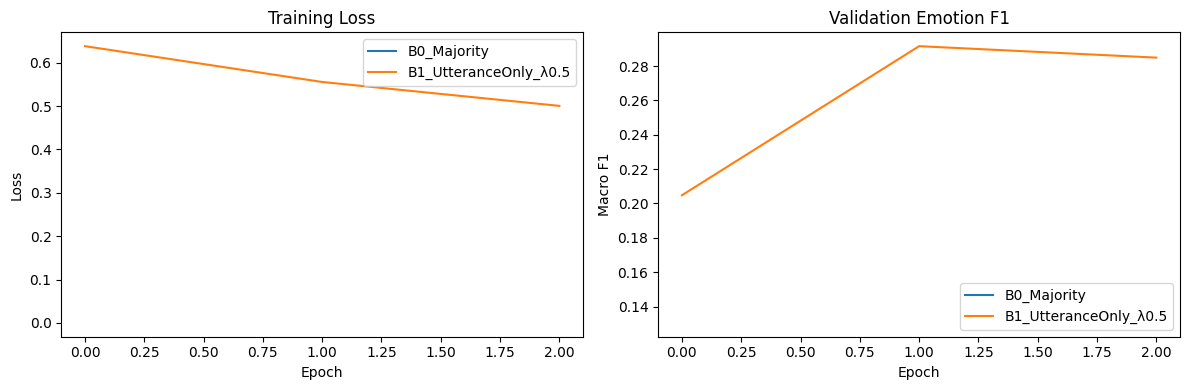


Breakdown analysis for best model: B1_UtteranceOnly_λ0.5

Performance by Dialogue Length for B1_UtteranceOnly_λ0.5:
category
long     0.398076
short    0.608715
Name: emotion_f1, dtype: float64


,dialog_id,length,emotion_f1,category
0,0,12,0.160000,long
1,1,4,0.428571,long
2,2,3,0.400000,short
3,3,7,0.461538,long
4,4,8,0.466667,long
...,...,...,...,...
995,995,7,0.461538,long
996,996,7,0.461538,long
997,997,7,0.461538,long
998,998,1,1.000000,short


In [ ]:
# ==================== MAIN EXECUTION FOR EXPERIMENTS ====================

print("\n" + "="*80)
print("STARTING BASELINE EXPERIMENTS")
print("="*80)






def collate_fn_b1(batch, tokenizer):
    """B1: Uses only current utterance (no context)"""
    current_turns = [item['current_turn'] for item in batch]
    shift_labels = [item['shift_label'] for item in batch]
    has_prev_flags = [item['has_prev'] for item in batch]
    prev_emotion_ids = [item['prev_emotion_id'] for item in batch]
    emotion_ids = [turn['emotion_id'] for turn in current_turns]

    # Create current turn strings
    current_strings = [f"{turn['speaker']}: {turn['text']}" for turn in current_turns]

    current_encodings = tokenizer(
        current_strings,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    return {
        'current_input_ids': current_encodings['input_ids'],
        'current_attention_mask': current_encodings['attention_mask'],
        'shift_labels': torch.tensor(shift_labels, dtype=torch.long),
        'emotion_labels': torch.tensor(emotion_ids, dtype=torch.long),
        'has_prev_mask': torch.tensor(has_prev_flags, dtype=torch.bool),
        'prev_emotion_ids': torch.tensor(prev_emotion_ids, dtype=torch.long),
        'dialog_ids': [item['dialog_id'] for item in batch],
        'turn_indices': [item['turn_idx'] for item in batch]
    }

def collate_fn_b2(batch, tokenizer):
    """B2: Uses context with speaker tags"""
    contexts = [item['context'] for item in batch]
    current_turns = [item['current_turn'] for item in batch]
    shift_labels = [item['shift_label'] for item in batch]
    has_prev_flags = [item['has_prev'] for item in batch]
    prev_emotion_ids = [item['prev_emotion_id'] for item in batch]
    emotion_ids = [turn['emotion_id'] for turn in current_turns]

    # Build context strings with speaker tags
    context_strings = []
    for ctx in contexts:
        parts = []
        for turn in ctx:
            if turn["speaker"] == "PAD":
                parts.append("")
            else:
                speaker_tag = '[SPK_A]' if turn['speaker'] == 'A' else '[SPK_B]'
                parts.append(f"{speaker_tag} {turn['text']}")
        context_strings.append(" [SEP] ".join(parts))

    # Tokenize contexts
    context_encodings = tokenizer(
        context_strings,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    return {
        'context_input_ids': context_encodings['input_ids'],
        'context_attention_mask': context_encodings['attention_mask'],
        'shift_labels': torch.tensor(shift_labels, dtype=torch.long),
        'emotion_labels': torch.tensor(emotion_ids, dtype=torch.long),
        'has_prev_mask': torch.tensor(has_prev_flags, dtype=torch.bool),
        'prev_emotion_ids': torch.tensor(prev_emotion_ids, dtype=torch.long),

        'dialog_ids': [item['dialog_id'] for item in batch],
        'turn_indices': [item['turn_idx'] for item in batch]
    }

# Create data loaders for B1 and B2
train_loader_b1 = DataLoader(
    train_dataset, batch_size=32, shuffle=True,
    collate_fn=lambda x: collate_fn_b1(x, roberta_tokenizer)
)
val_loader_b1 = DataLoader(valid_dataset, batch_size=32, shuffle=False,
                          collate_fn=lambda x: collate_fn_b1(x, roberta_tokenizer))
test_loader_b1 = DataLoader(test_dataset, batch_size=32, shuffle=False,
                           collate_fn=lambda x: collate_fn_b1(x, roberta_tokenizer))
train_loader_b2 = DataLoader(
    train_dataset, batch_size=32, shuffle=True,
    collate_fn=lambda x: collate_fn_b2(x, roberta_tokenizer)
)
val_loader_b2 = DataLoader(valid_dataset, batch_size=32, shuffle=False,
                          collate_fn=lambda x: collate_fn_b2(x, roberta_tokenizer))
test_loader_b2 = DataLoader(test_dataset, batch_size=32, shuffle=False,
                           collate_fn=lambda x: collate_fn_b2(x, roberta_tokenizer))


#  ######################################
# def debug_b2_model():
#     """Debug B2 model with a small batch"""
#     print("Debugging B2 model...")

#     # Test with a small batch on CPU first
#     debug_model = B2ContextualModel(num_emotions=7, lambda_shift=0.5, tokenizer=roberta_tokenizer)
#     debug_model.eval()

#     # Get a small batch
#     small_batch = next(iter(train_loader_b2))
#     print("Batch keys:", small_batch.keys())

#     # Check for any issues
#     print("Context input IDs shape:", small_batch['context_input_ids'].shape)
#     print("Context attention mask shape:", small_batch['context_attention_mask'].shape)

#     # Check token range
#     input_ids = small_batch['context_input_ids']
#     print("Min token ID:", input_ids.min().item())
#     print("Max token ID:", input_ids.max().item())
#     print("Tokenizer vocab size:", roberta_tokenizer.vocab_size)

#     print("Attention mask values:", torch.unique(small_batch['context_attention_mask']))
#     print("Emotion labels range:", small_batch['emotion_labels'].min(), "to", small_batch['emotion_labels'].max())
#     print("Shift labels unique:", torch.unique(small_batch['shift_labels']))

#     # Try forward pass on CPU
#     try:
#         with torch.no_grad():
#             outputs = debug_model(**small_batch)  # Already on CPU from collate_fn
#         print("B2 model works on CPU")
#         return True
#     except Exception as e:
#         print(f"B2 model fails on CPU: {e}")
#         import traceback
#         traceback.print_exc()
#         return False


# debug_b2_model()



# Run baseline experiments
print("Starting Baseline Experiments ...")
baseline_analyzer, baseline_models, baseline_path = run_experiment_grid(
    train_loader_b1, val_loader_b1, test_loader_b1,
    train_loader_b2, val_loader_b2, test_loader_b2,
    device
)

# Generate analysis
print("\n" + "="*80)
print("EXPERIMENT RESULTS SUMMARY")
print("="*80)

ablation_table = baseline_analyzer.create_ablation_table()
print(ablation_table)

baseline_analyzer.plot_learning_curves()

# Breakdown analysis for best model
best_model = ablation_table.loc[ablation_table['Emotion Macro-F1'].astype(float).idxmax(), 'Model']
print(f"\nBreakdown analysis for best model: {best_model}")
baseline_analyzer.breakdown_analysis(test_dataset, best_model)




In [ ]:
# # Quick diagnostic to understand B2's struggles
# def analyze_b2_failures():
#     """Compare B1 vs B2 predictions to understand context issues"""
#     b1_preds = baseline_analyzer.results['B1_UtteranceOnly_λ0.5']['test_metrics']['emotion_preds']
#     b2_preds = baseline_analyzer.results['B2_Contextual_λ0.5']['test_metrics']['emotion_preds']
#     labels = baseline_analyzer.results['B1_UtteranceOnly_λ0.5']['test_metrics']['emotion_labels']

#     # Find where B1 is right but B2 is wrong
#     b1_correct = (b1_preds == labels)
#     b2_wrong = (b2_preds != labels)
#     confusing_cases = np.where(b1_correct & b2_wrong)[0]

#     print(f"B1 correct but B2 wrong: {len(confusing_cases)} cases")
#     return confusing_cases

In [ ]:
# analyze_b2_failures()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from transformers import RobertaModel, RobertaTokenizer
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [ ]:
class MemoryAugmentedModel(BaseRobertaEmotionShift):
    """B3: Speaker-State Memory Model"""
    def __init__(self, num_emotions=7, lambda_shift=0.5, memory_type='GRU',
                 memory_dim=256, use_sentiment=False, truncate_memory=None):
        super().__init__(num_emotions, lambda_shift)

        self.memory_type = memory_type
        self.memory_dim = memory_dim
        self.use_sentiment = use_sentiment
        self.truncate_memory = truncate_memory  # Number of past turns to keep

        # Input dimension for memory (RoBERTa hidden size + sentiment if used)
        memory_input_dim = 768
        if use_sentiment:
            memory_input_dim += 3  # VADER: neg, neu, pos

        # Memory modules
        if memory_type == 'GRU':
            self.gru_cell = nn.GRUCell(memory_input_dim, memory_dim)
        elif memory_type == 'Gated':
            # Gated residual: s_{t+1} = s_t + σ(W[h_t;s_t]) ⊙ tanh(Vh_t)
            self.gate_w = nn.Linear(memory_input_dim + memory_dim, memory_dim)
            self.gate_v = nn.Linear(memory_input_dim, memory_dim)

        # Memory states storage
        self.speaker_memory = {}  # (dialog_id, speaker) -> memory state
        self.memory_history = {}  # For analysis

        # Fusion layer (h_t + s_t + h_ctx)
        fusion_dim = 768 + memory_dim + 768  # h_t + s_t + h_ctx
        self.emotion_head = nn.Linear(fusion_dim, num_emotions)
        self.shift_head = nn.Linear(fusion_dim, 1)

        # Sentiment analysis (VADER-like features)
        if use_sentiment:
            self.sentiment_processor = None  # Will be set externally

    def reset_memory(self, dialog_id=None):
        """Reset memory for specific dialog or all dialogs"""
        if dialog_id is None:
            self.speaker_memory = {}
            self.memory_history = {}
        else:
            # Remove all entries for this dialog_id
            keys_to_remove = [k for k in self.speaker_memory.keys() if k[0] == dialog_id]
            for k in keys_to_remove:
                del self.speaker_memory[k]
                if k in self.memory_history:
                    del self.memory_history[k]

    def get_speaker_memory(self, dialog_id, speaker):
        """Retrieve speaker memory state"""
        key = (dialog_id, speaker)
        if key not in self.speaker_memory:
            # Initialize with zeros
            self.speaker_memory[key] = torch.zeros(self.memory_dim,
                                                 device=next(self.parameters()).device)
            self.memory_history[key] = []
        return self.speaker_memory[key]

    def update_speaker_memory(self, dialog_id, speaker, new_memory):
        """Update speaker memory state"""
        key = (dialog_id, speaker)
        self.speaker_memory[key] = new_memory

        # Store history for analysis
        if key in self.memory_history:
            self.memory_history[key].append(new_memory.detach().cpu().numpy())

        # Truncate memory history if specified
        if (self.truncate_memory and key in self.memory_history and
            len(self.memory_history[key]) > self.truncate_memory):
            self.memory_history[key] = self.memory_history[key][-self.truncate_memory:]

    def extract_sentiment_features(self, texts):
        """Extract VADER-like sentiment features"""
        # Simple rule-based sentiment as placeholder - replace with actual VADER
        sentiments = []
        for text in texts:
            text_lower = text.lower()
            positive_words = ['good', 'great', 'excellent', 'happy', 'love', 'nice', 'awesome']
            negative_words = ['bad', 'terrible', 'hate', 'awful', 'horrible', 'sad']

            pos_count = sum(1 for word in positive_words if word in text_lower)
            neg_count = sum(1 for word in negative_words if word in text_lower)
            neu_count = max(0, 10 - pos_count - neg_count)  # Simple normalization

            total = pos_count + neg_count + neu_count + 1e-8
            sentiments.append([pos_count/total, neu_count/total, neg_count/total])

        return torch.tensor(sentiments, device=next(self.parameters()).device)

    def forward(self, input_ids, attention_mask, speaker_ids, dialog_ids,
                emotion_labels=None, shift_labels=None, has_prev_mask=None,
                texts=None, **kwargs):

        batch_size = input_ids.size(0)
        device = input_ids.device

        # Get RoBERTa embeddings
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        h_t = outputs.pooler_output  # [batch_size, 768]

        # Get context representation (mean pooling of last layer)
        h_ctx = outputs.last_hidden_state.mean(dim=1)  # [batch_size, 768]

        # Add sentiment features if enabled
        if self.use_sentiment and texts is not None:
            sentiment_features = self.extract_sentiment_features(texts)
            h_t = torch.cat([h_t, sentiment_features], dim=1)

        # Process each example in batch
        memory_states = []
        updated_memories = []

        for i in range(batch_size):
            dialog_id = dialog_ids[i]
            speaker = speaker_ids[i]

            # Retrieve current memory state
            s_t = self.get_speaker_memory(dialog_id, speaker)

            # Update memory state
            if self.memory_type == 'GRU':
                s_t_plus_1 = self.gru_cell(h_t[i].unsqueeze(0), s_t.unsqueeze(0)).squeeze(0)
            elif self.memory_type == 'Gated':
                # Gated residual update
                concat = torch.cat([h_t[i], s_t], dim=0)
                gate = torch.sigmoid(self.gate_w(concat))
                update = torch.tanh(self.gate_v(h_t[i]))
                s_t_plus_1 = s_t + gate * update
            else:
                # Fallback: no memory update
                s_t_plus_1 = s_t

            # Store for fusion and update
            memory_states.append(s_t)
            updated_memories.append((dialog_id, speaker, s_t_plus_1))

        # Stack memory states
        if memory_states:
            s_t_batch = torch.stack(memory_states)  # [batch_size, memory_dim]
        else:
            # Handle empty batch case
            s_t_batch = torch.zeros(batch_size, self.memory_dim, device=device)

        # Fusion: z_t = [h_t; s_t; h_ctx]
        z_t = torch.cat([h_t, s_t_batch, h_ctx], dim=1)  # [batch_size, 768 + memory_dim + 768]

        # Dropout
        z_t = self.dropout(z_t)

        # Prediction heads
        emotion_logits = self.emotion_head(z_t)
        shift_logits = self.shift_head(z_t).squeeze(-1)

        # Update memories after forward pass
        for dialog_id, speaker, new_memory in updated_memories:
            self.update_speaker_memory(dialog_id, speaker, new_memory)

        # Calculate loss
        loss = 0
        if emotion_labels is not None:
            loss_emotion = nn.CrossEntropyLoss()(emotion_logits, emotion_labels)
            loss += loss_emotion

        if shift_labels is not None and has_prev_mask is not None:
            valid_shift_mask = has_prev_mask & (shift_labels != -100)
            if valid_shift_mask.any():
                shift_loss = nn.BCEWithLogitsLoss()(
                    shift_logits[valid_shift_mask],
                    shift_labels[valid_shift_mask].float()
                )
                loss += self.lambda_shift * shift_loss

        return {
            'emotion_logits': emotion_logits,
            'shift_logits': shift_logits,
            'loss': loss,
            'memory_states': s_t_batch
        }

In [ ]:
# def debug_memory_model():
#     """Quick debug of memory model"""
#     print("Debugging Memory Model...")

#     # Test with a small batch
#     debug_model = MemoryAugmentedModel(
#         num_emotions=7,
#         lambda_shift=0.5,
#         memory_type='GRU',
#         memory_dim=256
#     )
#     debug_model.roberta.resize_token_embeddings(len(roberta_tokenizer))
#     debug_model.eval()

#     # Get a small batch
#     small_batch = next(iter(train_loader_b3))
#     print("Batch keys:", small_batch.keys())

#     # Check required fields
#     required_fields = ['input_ids', 'attention_mask', 'speaker_ids', 'dialog_ids']
#     for field in required_fields:
#         if field not in small_batch:
#             print(f"Missing required field: {field}")
#         else:
#             print(f"Found {field}")

#     # Try forward pass
#     try:
#         with torch.no_grad():
#             # Move tensors to CPU for debugging
#             debug_batch = {}
#             for k, v in small_batch.items():
#                 if isinstance(v, torch.Tensor):
#                     debug_batch[k] = v.cpu()
#                 else:
#                     debug_batch[k] = v

#             outputs = debug_model(**debug_batch)
#         print("Memory model works on CPU")
#         return True
#     except Exception as e:
#         print(f"Memory model fails: {e}")
#         import traceback
#         traceback.print_exc()
#         return False

# # Run debug before experiments
# debug_memory_model()

In [ ]:
class GRUMemoryWithSentimentModel(BaseRobertaEmotionShift):
    """B3: GRU Memory Model with Sentiment Features (Fixed dimensions)"""
    def __init__(self, num_emotions=7, lambda_shift=0.5, memory_dim=128, truncate_memory=None):
        super().__init__(num_emotions, lambda_shift)

        self.memory_dim = memory_dim
        self.truncate_memory = truncate_memory

        # Dimensions for sentiment: 768 (RoBERTa) + 3 (sentiment)
        self.gru_input_dim = 768 + 3
        self.gru_cell = nn.GRUCell(self.gru_input_dim, memory_dim)

        # Fusion dimension: (768+3) + memory_dim + 768
        self.fusion_dim = self.gru_input_dim + memory_dim + 768
        self.emotion_head = nn.Linear(self.fusion_dim, num_emotions)
        self.shift_head = nn.Linear(self.fusion_dim, 1)

        # Memory states storage
        self.speaker_memory = {}
        self.memory_history = {}

        # Initialize heads
        nn.init.xavier_uniform_(self.emotion_head.weight)
        nn.init.xavier_uniform_(self.shift_head.weight)

    def reset_memory(self, dialog_id=None):
        """Reset memory for specific dialog or all dialogs"""
        if dialog_id is None:
            self.speaker_memory = {}
            self.memory_history = {}
        else:
            keys_to_remove = [k for k in self.speaker_memory.keys() if k[0] == dialog_id]
            for k in keys_to_remove:
                del self.speaker_memory[k]
                if k in self.memory_history:
                    del self.memory_history[k]

    def get_speaker_memory(self, dialog_id, speaker):
        """Retrieve speaker memory state"""
        key = (dialog_id, speaker)
        if key not in self.speaker_memory:
            self.speaker_memory[key] = torch.zeros(self.memory_dim,
                                                 device=next(self.parameters()).device)
            self.memory_history[key] = []
        return self.speaker_memory[key]

    def update_speaker_memory(self, dialog_id, speaker, new_memory):
        """Update speaker memory state"""
        key = (dialog_id, speaker)
        self.speaker_memory[key] = new_memory

        if key in self.memory_history:
            self.memory_history[key].append(new_memory.detach().cpu().numpy())

        if (self.truncate_memory and key in self.memory_history and
            len(self.memory_history[key]) > self.truncate_memory):
            self.memory_history[key] = self.memory_history[key][-self.truncate_memory:]

    def extract_sentiment_features(self, texts):
        """Extract VADER-like sentiment features"""
        sentiments = []
        for text in texts:
            text_lower = text.lower()
            positive_words = ['good', 'great', 'excellent', 'happy', 'love', 'nice', 'awesome', 'amazing', 'wonderful']
            negative_words = ['bad', 'terrible', 'hate', 'awful', 'horrible', 'sad', 'angry', 'disgusting']

            pos_count = sum(1 for word in positive_words if word in text_lower)
            neg_count = sum(1 for word in negative_words if word in text_lower)
            neu_count = max(1, 10 - pos_count - neg_count)

            total = pos_count + neg_count + neu_count + 1e-8
            sentiments.append([pos_count/total, neu_count/total, neg_count/total])

        return torch.tensor(sentiments, device=next(self.parameters()).device)

    def forward(self, input_ids, attention_mask, speaker_ids, dialog_ids,
                emotion_labels=None, shift_labels=None, has_prev_mask=None,
                texts=None, **kwargs):

        batch_size = input_ids.size(0)
        device = input_ids.device

        # Get RoBERTa embeddings
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        h_t = outputs.pooler_output  # [batch_size, 768]
        h_ctx = outputs.last_hidden_state.mean(dim=1)  # [batch_size, 768]

        # Extract and add sentiment features
        sentiment_features = self.extract_sentiment_features(texts)  # [batch_size, 3]
        h_t_with_sentiment = torch.cat([h_t, sentiment_features], dim=1)  # [batch_size, 771]


        memory_states = []
        updated_memories = []

        for i in range(batch_size):
            dialog_id = dialog_ids[i]
            speaker = speaker_ids[i]

            s_t = self.get_speaker_memory(dialog_id, speaker)
            s_t = s_t.to(device)

            # GRU update with sentiment features
            s_t_plus_1 = self.gru_cell(h_t_with_sentiment[i].unsqueeze(0), s_t.unsqueeze(0)).squeeze(0)

            memory_states.append(s_t)
            updated_memories.append((dialog_id, speaker, s_t_plus_1))

        # Stack memory states
        if memory_states:
            s_t_batch = torch.stack(memory_states)  # [batch_size, memory_dim]
        else:
            s_t_batch = torch.zeros(batch_size, self.memory_dim, device=device)

        # Fusion: z_t = [h_t_with_sentiment; s_t; h_ctx]
        z_t = torch.cat([h_t_with_sentiment, s_t_batch, h_ctx], dim=1)  # [batch_size, 771 + 128 + 768 = 1667]

        # Dropout
        z_t = self.dropout(z_t)

        # Prediction heads
        emotion_logits = self.emotion_head(z_t)  # [batch_size, 7]
        shift_logits = self.shift_head(z_t).squeeze(-1)  # [batch_size]

        # Update memories after forward pass
        for dialog_id, speaker, new_memory in updated_memories:
            self.update_speaker_memory(dialog_id, speaker, new_memory)

        # Calculate loss
        loss = 0
        if emotion_labels is not None:
            loss_emotion = nn.CrossEntropyLoss()(emotion_logits, emotion_labels)
            loss += loss_emotion

        if shift_labels is not None and has_prev_mask is not None:
            valid_shift_mask = has_prev_mask & (shift_labels != -100)
            if valid_shift_mask.any():
                shift_loss = nn.BCEWithLogitsLoss()(
                    shift_logits[valid_shift_mask],
                    shift_labels[valid_shift_mask].float()
                )
                loss += self.lambda_shift * shift_loss

        return {
            'emotion_logits': emotion_logits,
            'shift_logits': shift_logits,
            'loss': loss,
            'memory_states': s_t_batch
        }

In [ ]:
class EnhancedExperimentRunner(ExperimentRunner):
    def __init__(self, model, train_loader, val_loader, test_loader, device):
        super().__init__(model, train_loader, val_loader, test_loader, device)
        self.analysis_results = {}

    def enhanced_evaluate(self, loader, split_name="Validation"):
        """Comprehensive evaluation with all required metrics"""
        self.model.eval()

        # Storage for all predictions and labels
        all_emotion_preds = []
        all_emotion_labels = []
        all_emotion_probs = []
        all_shift_preds = []
        all_shift_labels = []
        all_shift_probs = []
        all_has_prev = []
        all_dialog_ids = []
        all_turn_indices = []
        all_speakers = []
        all_texts = []

        with torch.no_grad():
            for batch in tqdm(loader, desc=f"Evaluating {split_name}"):

                tensor_batch = {}
                for k, v in batch.items():
                    if isinstance(v, torch.Tensor):
                        tensor_batch[k] = v.to(self.device)
                    else:
                        tensor_batch[k] = v

                # Reset memory for each batch in evaluation
                if hasattr(self.model, 'reset_memory'):
                    self.model.reset_memory()

                outputs = self.model(**tensor_batch)

                # Store predictions and labels
                emotion_probs = torch.softmax(outputs['emotion_logits'], dim=1)
                emotion_preds = torch.argmax(emotion_probs, dim=1)

                shift_probs = torch.sigmoid(outputs['shift_logits'])
                shift_preds = (shift_probs > 0.5).int()

                all_emotion_preds.extend(emotion_preds.cpu().numpy())
                all_emotion_labels.extend(tensor_batch['emotion_labels'].cpu().numpy())
                all_emotion_probs.extend(emotion_probs.cpu().numpy())
                all_shift_preds.extend(shift_preds.cpu().numpy())
                all_shift_labels.extend(tensor_batch['shift_labels'].cpu().numpy())
                all_shift_probs.extend(shift_probs.cpu().numpy())
                all_has_prev.extend(tensor_batch['has_prev_mask'].cpu().numpy())
                all_dialog_ids.extend(batch.get('dialog_ids', []))
                all_turn_indices.extend(batch.get('turn_indices', []))
                all_speakers.extend(batch.get('speaker_ids', []))
                all_texts.extend(batch.get('texts', []))

        # Convert to numpy arrays
        all_emotion_preds = np.array(all_emotion_preds)
        all_emotion_labels = np.array(all_emotion_labels)
        all_emotion_probs = np.array(all_emotion_probs)
        all_shift_preds = np.array(all_shift_preds)
        all_shift_labels = np.array(all_shift_labels)
        all_shift_probs = np.array(all_shift_probs)
        all_has_prev = np.array(all_has_prev)

        # Filter shift metrics for valid examples
        valid_shift_mask = (all_has_prev == 1) & (all_shift_labels != -100)
        valid_shift_preds = all_shift_preds[valid_shift_mask]
        valid_shift_labels = all_shift_labels[valid_shift_mask]
        valid_shift_probs = all_shift_probs[valid_shift_mask]

        # Primary metrics
        emotion_f1 = f1_score(all_emotion_labels, all_emotion_preds, average='macro')

        if len(valid_shift_labels) > 0:
            shift_f1 = f1_score(valid_shift_labels, valid_shift_preds)
            precision, recall, _ = precision_recall_curve(valid_shift_labels, valid_shift_probs)
            shift_auprc = auc(recall, precision)
        else:
            shift_f1 = 0.0
            shift_auprc = 0.0

        # Secondary metrics
        per_emotion_f1 = f1_score(all_emotion_labels, all_emotion_preds, average=None)
        emotion_cm = confusion_matrix(all_emotion_labels, all_emotion_preds)

        # Shift calibration
        shift_calibration = None
        if len(valid_shift_labels) > 0:
            prob_true, prob_pred = calibration_curve(valid_shift_labels, valid_shift_probs, n_bins=10)
            shift_calibration = (prob_true, prob_pred)

        # Breakdown analyses
        breakdowns = self._compute_breakdowns(
            all_emotion_preds, all_emotion_labels, all_shift_preds, all_shift_labels,
            valid_shift_mask, all_dialog_ids, all_turn_indices, all_speakers
        )

        results = {
            # Primary metrics
            'emotion_macro_f1': emotion_f1,
            'shift_f1': shift_f1,
            'shift_auprc': shift_auprc,

            # Secondary metrics
            'per_emotion_f1': per_emotion_f1,
            'emotion_confusion_matrix': emotion_cm,
            'shift_calibration': shift_calibration,

            # Raw data for case studies
            'emotion_preds': all_emotion_preds,
            'emotion_labels': all_emotion_labels,
            'emotion_probs': all_emotion_probs,
            'shift_preds': all_shift_preds,
            'shift_labels': all_shift_labels,
            'shift_probs': all_shift_probs,
            'valid_shift_mask': valid_shift_mask,
            'dialog_ids': all_dialog_ids,
            'turn_indices': all_turn_indices,
            'speakers': all_speakers,
            'texts': all_texts,

            # Breakdowns
            'breakdowns': breakdowns
        }

        return results

    def _compute_breakdowns(self, emotion_preds, emotion_labels, shift_preds, shift_labels,
                           valid_shift_mask, dialog_ids, turn_indices, speakers):
        """Compute detailed breakdown analyses"""
        breakdowns = {}

        # Dialogue length breakdown
        dialog_lengths = defaultdict(list)
        for i, dialog_id in enumerate(dialog_ids):
            dialog_lengths[dialog_id].append(i)

        length_metrics = []
        for dialog_id, indices in dialog_lengths.items():
            if len(indices) == 0:
                continue

            dialog_emotion_preds = emotion_preds[indices]
            dialog_emotion_labels = emotion_labels[indices]

            emotion_f1 = f1_score(dialog_emotion_labels, dialog_emotion_preds, average='macro')

            length_metrics.append({
                'dialog_id': dialog_id,
                'length': len(indices),
                'emotion_f1': emotion_f1,
                'category': 'short' if len(indices) <= 3 else 'long'
            })

        breakdowns['dialogue_length'] = pd.DataFrame(length_metrics)

        # Turn position breakdown
        turn_positions = []
        max_turn = max(turn_indices) if turn_indices else 0
        for i, turn_idx in enumerate(turn_indices):
            if max_turn > 0:
                position = 'early' if turn_idx < max_turn // 2 else 'late'
            else:
                position = 'early'

            turn_positions.append({
                'turn_idx': turn_idx,
                'position': position,
                'emotion_pred': emotion_preds[i],
                'emotion_label': emotion_labels[i]
            })

        turn_df = pd.DataFrame(turn_positions)
        breakdowns['turn_position'] = turn_df

        # Speaker breakdown
        speaker_metrics = []
        unique_speakers = set(speakers)
        for speaker in unique_speakers:
            speaker_mask = [s == speaker for s in speakers]
            if sum(speaker_mask) > 0:
                speaker_emotion_f1 = f1_score(
                    emotion_labels[speaker_mask],
                    emotion_preds[speaker_mask],
                    average='macro'
                )
                speaker_metrics.append({
                    'speaker': speaker,
                    'emotion_f1': speaker_emotion_f1,
                    'num_turns': sum(speaker_mask)
                })

        breakdowns['speaker'] = pd.DataFrame(speaker_metrics)

        return breakdowns

    def run_enhanced_experiment(self, num_epochs=3, model_name="model"):
        """Run experiment with comprehensive evaluation"""
        print(f"Starting enhanced experiment for {model_name}")

        best_val_f1 = 0
        results = {
            'train_losses': [],
            'val_metrics': [],
            'test_metrics': None,
            'case_studies': None
        }

        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch + 1}/{num_epochs}")

            # Training
            train_loss = self.train_epoch()
            results['train_losses'].append(train_loss)
            print(f"Train Loss: {train_loss:.4f}")

            # Enhanced validation
            val_metrics = self.enhanced_evaluate(self.val_loader, "Validation")
            results['val_metrics'].append(val_metrics)

            print(f"Val Emotion F1: {val_metrics['emotion_macro_f1']:.4f}")
            print(f"Val Shift F1: {val_metrics['shift_f1']:.4f}")
            print(f"Val Shift AUPRC: {val_metrics['shift_auprc']:.4f}")

            # Save best model
            current_f1 = val_metrics['emotion_macro_f1'] + val_metrics['shift_f1']
            if current_f1 > best_val_f1:
                best_val_f1 = current_f1
                torch.save(self.model.state_dict(), f"{model_name}_best.pth")

        # Final enhanced test evaluation
        self.model.load_state_dict(torch.load(f"{model_name}_best.pth"))
        test_metrics = self.enhanced_evaluate(self.test_loader, "Test")
        results['test_metrics'] = test_metrics

        # Generate case studies
        results['case_studies'] = self.generate_case_studies(test_metrics)

        print(f"\nFinal Test Results for {model_name}:")
        self._print_comprehensive_results(test_metrics)

        return results

    def _print_comprehensive_results(self, metrics):
        """Print detailed results"""
        print(f"Emotion Macro-F1: {metrics['emotion_macro_f1']:.4f}")
        print(f"Shift F1: {metrics['shift_f1']:.4f}")
        print(f"Shift AUPRC: {metrics['shift_auprc']:.4f}")

        print("\nPer-Emotion F1 Scores:")
        emotions = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
        for i, emotion in enumerate(emotions):
            print(f"  {emotion}: {metrics['per_emotion_f1'][i]:.4f}")

        print("\nBreakdown Analyses:")
        print("Dialogue Length:")
        print(metrics['breakdowns']['dialogue_length'].groupby('category')['emotion_f1'].mean())

        print("\nSpeaker Performance:")
        print(metrics['breakdowns']['speaker'])

    def generate_case_studies(self, test_metrics, num_cases=6):
        """Generate case studies showing where memory helped vs hurt"""

        if hasattr(self, 'baseline_predictions'):

            baseline_emotion_preds = self.baseline_predictions['emotion_preds']
            memory_emotion_preds = test_metrics['emotion_preds']
            emotion_labels = test_metrics['emotion_labels']


            baseline_correct = (baseline_emotion_preds == emotion_labels)
            memory_correct = (memory_emotion_preds == emotion_labels)

            improved_cases = np.where(~baseline_correct & memory_correct)[0]
            worsened_cases = np.where(baseline_correct & ~memory_correct)[0]

            case_studies = {
                'improved': improved_cases[:min(3, len(improved_cases))],
                'worsened': worsened_cases[:min(3, len(worsened_cases))]
            }

            return case_studies
        return None

In [ ]:
class EnhancedExperimentAnalyzer(ExperimentAnalyzer):
    def __init__(self):
        super().__init__()
        self.case_studies = {}

    def add_experiment(self, name, results):
        super().add_experiment(name, results)
        if 'case_studies' in results:
            self.case_studies[name] = results['case_studies']

    def create_comprehensive_ablation_table(self):
        """Create detailed ablation table"""
        rows = []
        for model_name, result in self.results.items():
            test_metrics = result['test_metrics']

            row = {
                'Model': model_name,
                'Emotion Macro-F1': f"{test_metrics['emotion_macro_f1']:.4f}",
                'Shift F1': f"{test_metrics['shift_f1']:.4f}",
                'Shift AUPRC': f"{test_metrics['shift_auprc']:.4f}"
            }

            # Add per-emotion F1 scores
            emotions = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
            for i, emotion in enumerate(emotions):
                row[f'{emotion}_F1'] = f"{test_metrics['per_emotion_f1'][i]:.4f}"

            rows.append(row)

        return pd.DataFrame(rows)

    def plot_comprehensive_analysis(self, model_name):
        """Generate all comprehensive plots for a model"""
        if model_name not in self.results:
            return

        test_metrics = self.results[model_name]['test_metrics']

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle(f'Comprehensive Analysis: {model_name}', fontsize=16)

        # 1. Confusion Matrix
        self._plot_confusion_matrix(test_metrics['emotion_confusion_matrix'], axes[0, 0])

        # 2. Shift Calibration
        self._plot_calibration_curve(test_metrics['shift_calibration'], axes[0, 1])

        # 3. Dialogue Length Performance
        self._plot_dialogue_length_breakdown(test_metrics['breakdowns']['dialogue_length'], axes[0, 2])

        # 4. Per-Emotion F1
        self._plot_per_emotion_f1(test_metrics['per_emotion_f1'], axes[1, 0])

        # 5. Turn Position Analysis
        self._plot_turn_position_analysis(test_metrics['breakdowns']['turn_position'], axes[1, 1])

        # 6. Speaker Performance
        self._plot_speaker_analysis(test_metrics['breakdowns']['speaker'], axes[1, 2])

        plt.tight_layout()
        plt.show()

    def _plot_confusion_matrix(self, cm, ax):
        """Plot confusion matrix"""
        emotions = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions, ax=ax)
        ax.set_title('Confusion Matrix')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    def _plot_calibration_curve(self, calibration_data, ax):
        """Plot calibration curve for shift detection"""
        if calibration_data is None:
            ax.text(0.5, 0.5, 'No calibration data', ha='center', va='center')
            ax.set_title('Shift Calibration Curve')
            return

        prob_true, prob_pred = calibration_data
        ax.plot(prob_pred, prob_true, 's-', label='Model')
        ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Fraction of positives')
        ax.set_title('Shift Calibration Curve')
        ax.legend()
        ax.grid(True)

    def _plot_dialogue_length_breakdown(self, length_df, ax):
        """Plot performance by dialogue length"""
        if len(length_df) > 0:
            sns.boxplot(data=length_df, x='category', y='emotion_f1', ax=ax)
            ax.set_title('Performance by Dialogue Length')
            ax.set_xlabel('Dialogue Length Category')
            ax.set_ylabel('Emotion F1 Score')

    def _plot_per_emotion_f1(self, per_emotion_f1, ax):
        """Plot per-emotion F1 scores"""
        emotions = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
        colors = plt.cm.Set3(np.linspace(0, 1, len(emotions)))

        bars = ax.bar(emotions, per_emotion_f1, color=colors)
        ax.set_title('Per-Emotion F1 Scores')
        ax.set_ylabel('F1 Score')
        ax.set_xticklabels(emotions, rotation=45)


        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom')

    def _plot_turn_position_analysis(self, turn_df, ax):
        """Plot performance by turn position"""
        if len(turn_df) > 0:
            position_f1 = turn_df.groupby('position').apply(
                lambda x: f1_score(x['emotion_label'], x['emotion_pred'], average='macro')
            )
            position_f1.plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral'])
            ax.set_title('Performance by Turn Position')
            ax.set_ylabel('Emotion F1 Score')
            ax.set_xlabel('Turn Position')

    def _plot_speaker_analysis(self, speaker_df, ax):
        """Plot performance by speaker"""
        if len(speaker_df) > 0:
            ax.bar(speaker_df['speaker'], speaker_df['emotion_f1'],
                  color=['lightblue', 'lightpink'])
            ax.set_title('Performance by Speaker')
            ax.set_ylabel('Emotion F1 Score')
            ax.set_xlabel('Speaker')

    def plot_memory_trajectories(self, model_name, dialog_ids, emotion_labels):
        """Plot memory state trajectories for specific dialogues"""
        if model_name not in self.results:
            return


        print("Memory trajectory plotting requires storing memory states during inference")

In [ ]:
def run_memory_experiment_grid(train_loader_b3, val_loader_b3, test_loader_b3, device):
    """Run memory model experiments with comprehensive evaluation"""
    analyzer = EnhancedExperimentAnalyzer()


    trained_models = {}


    experiments = [
        # Base memory model with GRU
        {'name': 'B3_Memory_GRU_λ0.5', 'model_class': MemoryAugmentedModel,
         'kwargs': {'lambda_shift': 0.5, 'memory_type': 'GRU', 'memory_dim': 128}},

        # Memory model with gated residual
        {'name': 'B3_Memory_Gated_λ0.5', 'model_class': MemoryAugmentedModel,
         'kwargs': {'lambda_shift': 0.5, 'memory_type': 'Gated', 'memory_dim': 128}},

        # Memory model with truncated memory
        {'name': 'B3_Memory_GRU_Trunc5_λ0.5', 'model_class': MemoryAugmentedModel,
         'kwargs': {'lambda_shift': 0.5, 'memory_type': 'GRU', 'memory_dim': 128, 'truncate_memory': 5}},

        # Memory model with sentiment
        {'name': 'B3_Memory_GRU_Sentiment_λ0.5', 'model_class': GRUMemoryWithSentimentModel,
         'kwargs': {'lambda_shift': 0.5, 'memory_dim': 128}},
    ]


    for exp_config in experiments:
        print(f"\n{'='*50}")
        print(f"Running: {exp_config['name']}")
        print(f"{'='*50}")

        model = exp_config['model_class'](**exp_config['kwargs'])
        model.roberta.resize_token_embeddings(len(roberta_tokenizer))


        runner = EnhancedExperimentRunner(model, train_loader_b3, val_loader_b3, test_loader_b3, device)
        results = runner.run_enhanced_experiment(num_epochs=3, model_name=exp_config['name'])

        analyzer.add_experiment(exp_config['name'], results)
        trained_models[exp_config['name']] = model


        analyzer.plot_comprehensive_analysis(exp_config['name'])


    analyzer_path, saved_models = saver.save_memory_experiments(analyzer, trained_models)

    return analyzer, trained_models, analyzer_path


In [ ]:
def collate_fn_b3(batch, tokenizer):
    """B3: Memory model with speaker information"""
    contexts = [item['context'] for item in batch]
    current_turns = [item['current_turn'] for item in batch]
    shift_labels = [item['shift_label'] for item in batch]
    has_prev_flags = [item['has_prev'] for item in batch]
    prev_emotion_ids = [item['prev_emotion_id'] for item in batch]
    emotion_ids = [turn['emotion_id'] for turn in current_turns]
    speaker_ids = [turn['speaker'] for turn in current_turns]
    dialog_ids = [item['dialog_id'] for item in batch]
    turn_indices = [item['turn_idx'] for item in batch]
    texts = [turn['text'] for turn in current_turns]


    context_strings = []
    for ctx in contexts:
        parts = []
        for turn in ctx:
            if turn["speaker"] == "PAD":
                parts.append("")
            else:
                speaker_tag = '[SPK_A]' if turn['speaker'] == 'A' else '[SPK_B]'
                parts.append(f"{speaker_tag} {turn['text']}")
        context_strings.append(" [SEP] ".join(parts))


    context_encodings = tokenizer(
        context_strings,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    return {
        'input_ids': context_encodings['input_ids'],
        'attention_mask': context_encodings['attention_mask'],
        'speaker_ids': speaker_ids,
        'dialog_ids': dialog_ids,
        'turn_indices': turn_indices,
        'texts': texts,
        'shift_labels': torch.tensor(shift_labels, dtype=torch.long),
        'emotion_labels': torch.tensor(emotion_ids, dtype=torch.long),
        'has_prev_mask': torch.tensor(has_prev_flags, dtype=torch.bool),
        'prev_emotion_ids': torch.tensor(prev_emotion_ids, dtype=torch.long),
    }


 Starting Memory Experiments with Saving...

Running: B3_Memory_GRU_λ0.5


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting enhanced experiment for B3_Memory_GRU_λ0.5

Epoch 1/3


Training: 100%|██████████| 6637/6637 [27:34<00:00,  4.01it/s]


Train Loss: 0.6953


...

Train Loss: 0.5650


Evaluating Validation: 100%|██████████| 619/619 [00:36<00:00, 16.83it/s]


Val Emotion F1: 0.1791
Val Shift F1: 0.1348
Val Shift AUPRC: 0.3666


Evaluating Test: 100%|██████████| 578/578 [00:34<00:00, 16.80it/s]



Final Test Results for B3_Memory_GRU_λ0.5:
Emotion Macro-F1: 0.1972
Shift F1: 0.0937
Shift AUPRC: 0.3235

Per-Emotion F1 Scores:
  anger: 0.9151
  disgust: 0.0000
  fear: 0.0000
  joy: 0.0000
  neutral: 0.3650
  sadness: 0.0000
  surprise: 0.1000

Breakdown Analyses:
Dialogue Length:
category
long     0.714288
short    0.798366
Name: emotion_f1, dtype: float64

Speaker Performance:
  speaker  emotion_f1  num_turns
0       B    0.213421       2066
1       A    0.178837       2555


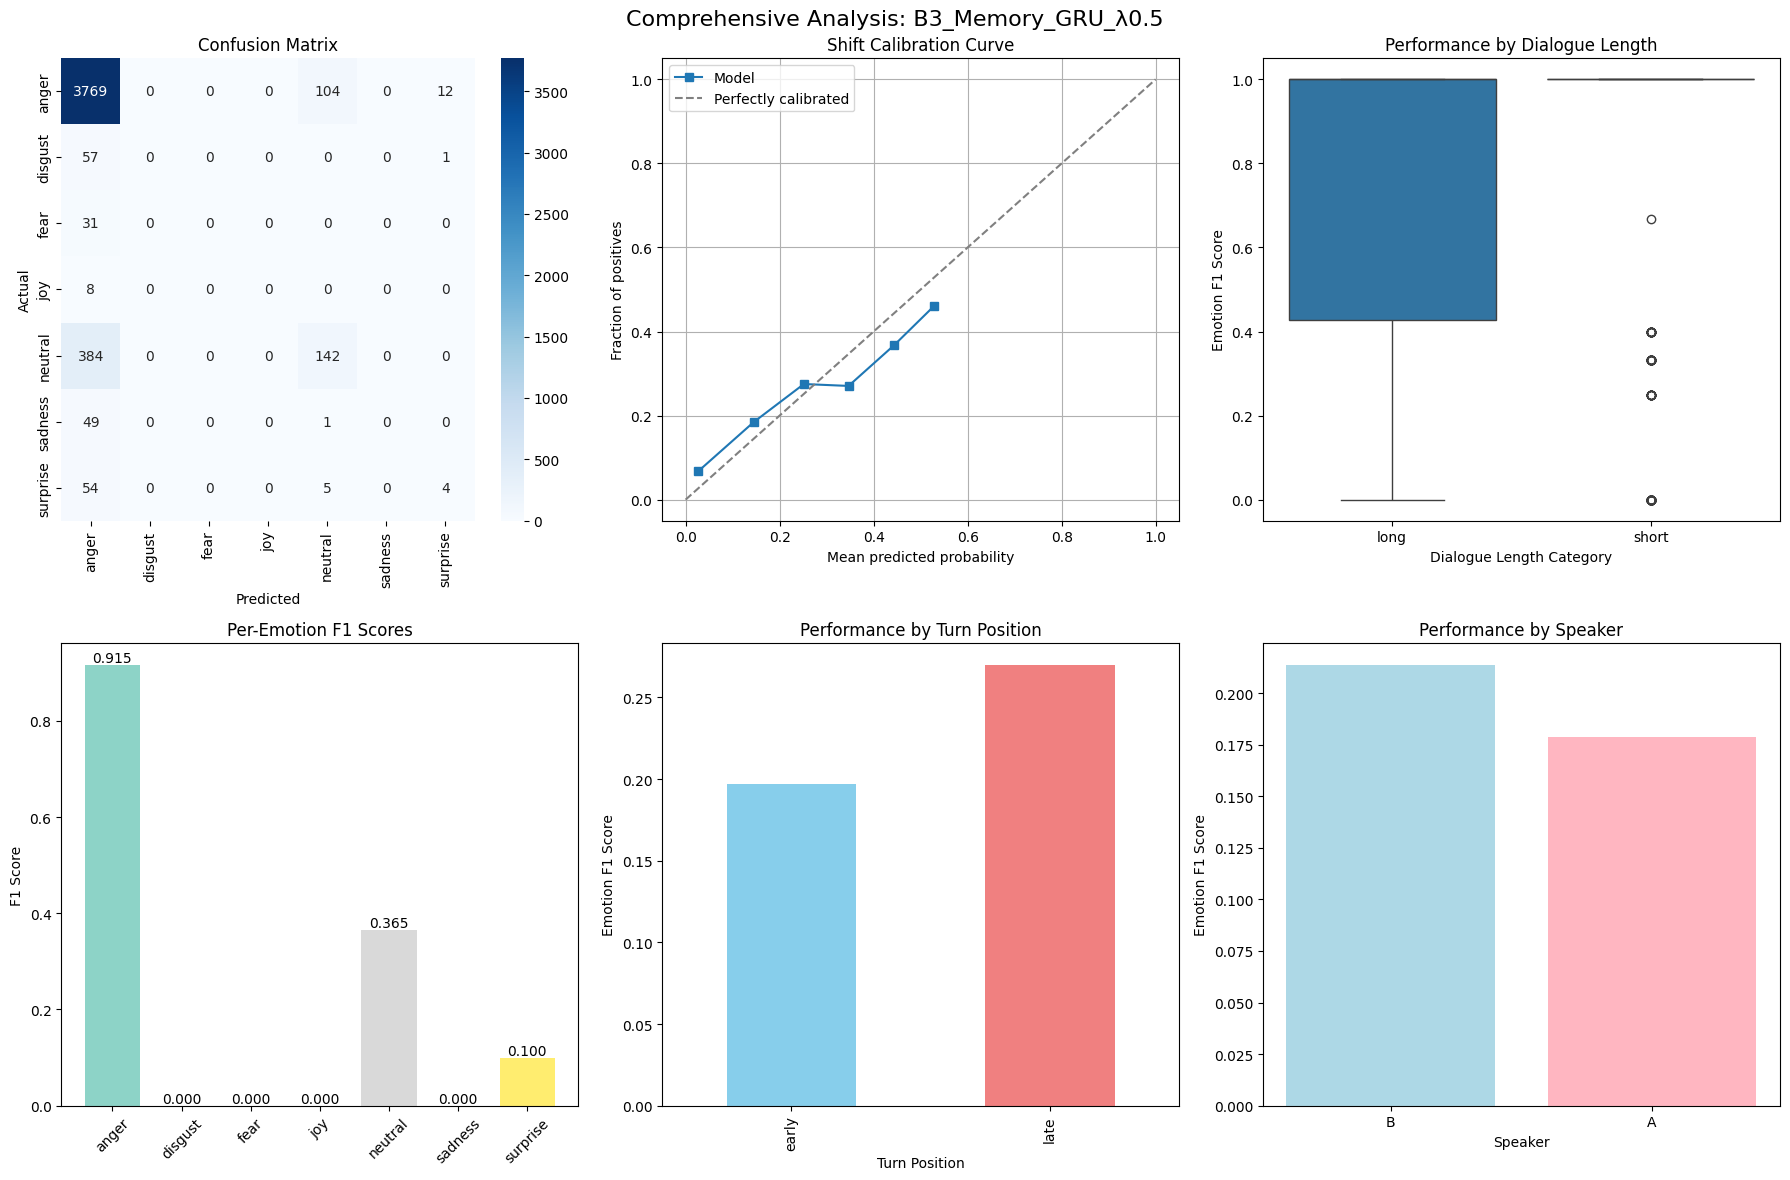


Running: B3_Memory_Gated_λ0.5


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting enhanced experiment for B3_Memory_Gated_λ0.5

Epoch 1/3


Training: 100%|██████████| 6637/6637 [27:46<00:00,  3.98it/s]


Train Loss: 0.7046


...

Train Loss: 0.5964


Evaluating Validation: 100%|██████████| 619/619 [00:37<00:00, 16.71it/s]


Val Emotion F1: 0.1358
Val Shift F1: 0.0000
Val Shift AUPRC: 0.2402


Evaluating Test: 100%|██████████| 578/578 [00:34<00:00, 16.73it/s]



Final Test Results for B3_Memory_Gated_λ0.5:
Emotion Macro-F1: 0.1735
Shift F1: 0.0000
Shift AUPRC: 0.3287

Per-Emotion F1 Scores:
  anger: 0.9190
  disgust: 0.0000
  fear: 0.0000
  joy: 0.0000
  neutral: 0.2954
  sadness: 0.0000
  surprise: 0.0000

Breakdown Analyses:
Dialogue Length:
category
long     0.721646
short    0.803413
Name: emotion_f1, dtype: float64

Speaker Performance:
  speaker  emotion_f1  num_turns
0       B    0.183550       2066
1       A    0.163099       2555


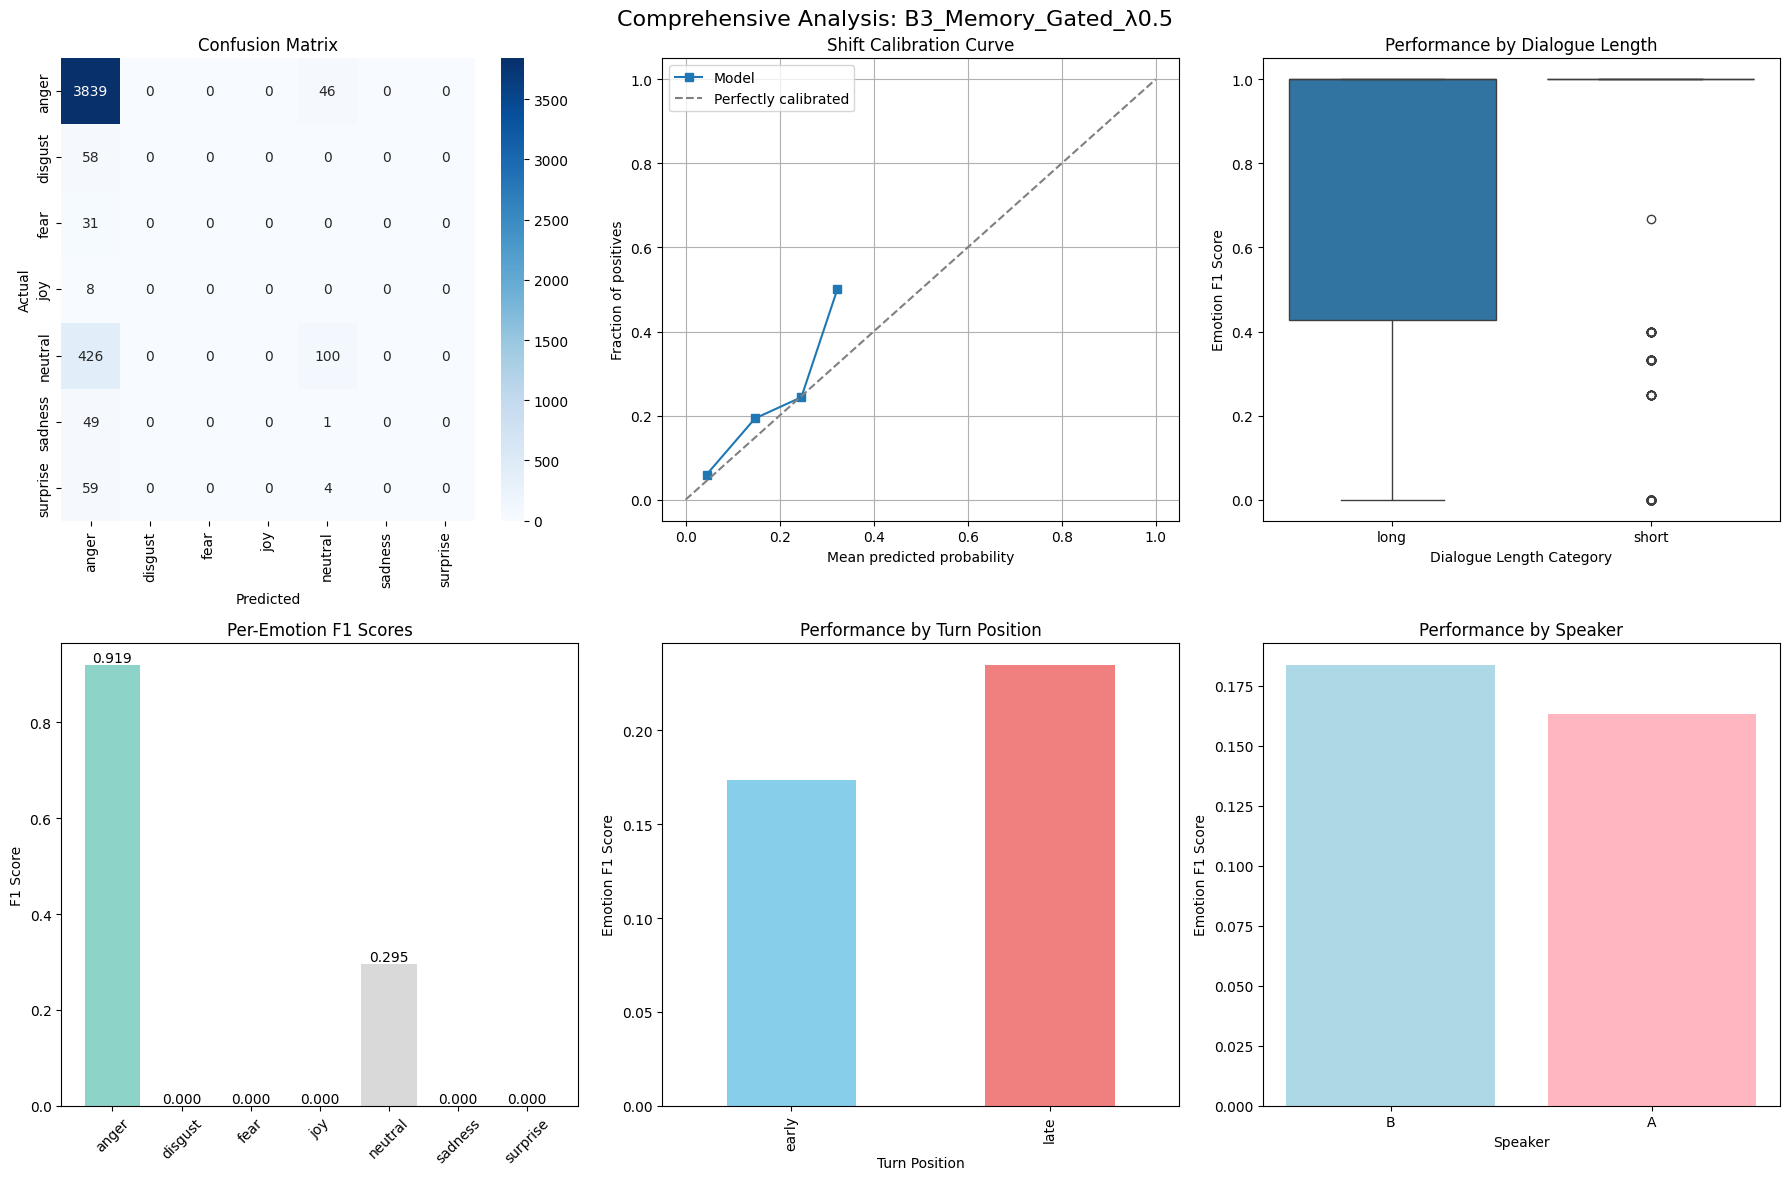


Running: B3_Memory_GRU_Trunc5_λ0.5


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting enhanced experiment for B3_Memory_GRU_Trunc5_λ0.5

Epoch 1/3


Training: 100%|██████████| 6637/6637 [27:40<00:00,  4.00it/s]


Train Loss: 0.6953


...

Train Loss: 0.5671


Evaluating Validation: 100%|██████████| 619/619 [00:37<00:00, 16.64it/s]


Val Emotion F1: 0.1677
Val Shift F1: 0.0930
Val Shift AUPRC: 0.3686


Evaluating Test: 100%|██████████| 578/578 [00:34<00:00, 16.60it/s]



Final Test Results for B3_Memory_GRU_Trunc5_λ0.5:
Emotion Macro-F1: 0.2004
Shift F1: 0.0750
Shift AUPRC: 0.3344

Per-Emotion F1 Scores:
  anger: 0.9190
  disgust: 0.0000
  fear: 0.0625
  joy: 0.0000
  neutral: 0.3617
  sadness: 0.0000
  surprise: 0.0597

Breakdown Analyses:
Dialogue Length:
category
long     0.726647
short    0.802179
Name: emotion_f1, dtype: float64

Speaker Performance:
  speaker  emotion_f1  num_turns
0       B    0.222591       2066
1       A    0.173916       2555


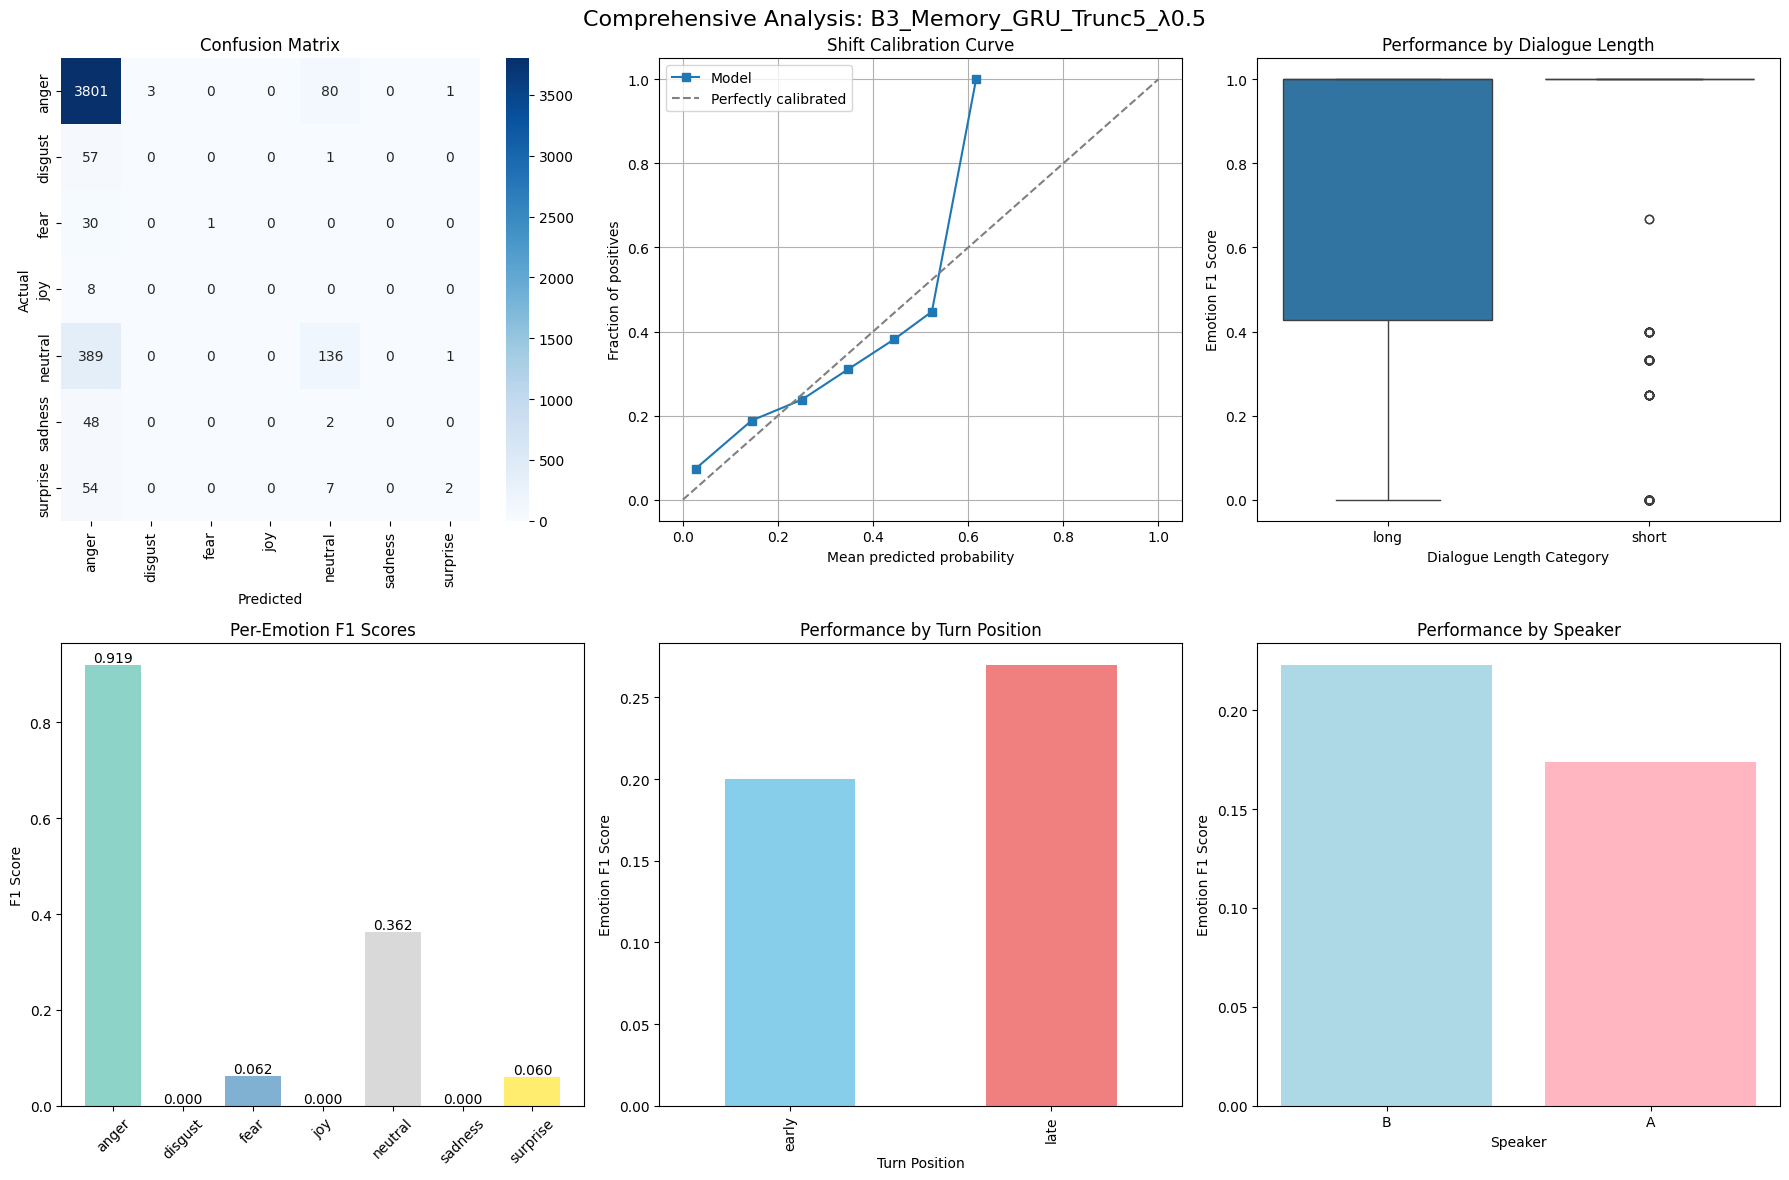


Running: B3_Memory_GRU_Sentiment_λ0.5


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting enhanced experiment for B3_Memory_GRU_Sentiment_λ0.5

Epoch 1/3


Training: 100%|██████████| 6637/6637 [27:57<00:00,  3.96it/s]


Train Loss: 0.7026


...

Train Loss: 0.5639


Evaluating Validation: 100%|██████████| 619/619 [00:37<00:00, 16.42it/s]


Val Emotion F1: 0.1785
Val Shift F1: 0.0636
Val Shift AUPRC: 0.3530


Evaluating Test: 100%|██████████| 578/578 [00:34<00:00, 16.53it/s]



Final Test Results for B3_Memory_GRU_Sentiment_λ0.5:
Emotion Macro-F1: 0.2073
Shift F1: 0.2576
Shift AUPRC: 0.3073

Per-Emotion F1 Scores:
  anger: 0.9124
  disgust: 0.0923
  fear: 0.0625
  joy: 0.0000
  neutral: 0.3842
  sadness: 0.0000
  surprise: 0.0000

Breakdown Analyses:
Dialogue Length:
category
long     0.721537
short    0.792593
Name: emotion_f1, dtype: float64

Speaker Performance:
  speaker  emotion_f1  num_turns
0       B    0.232465       2066
1       A    0.184714       2555


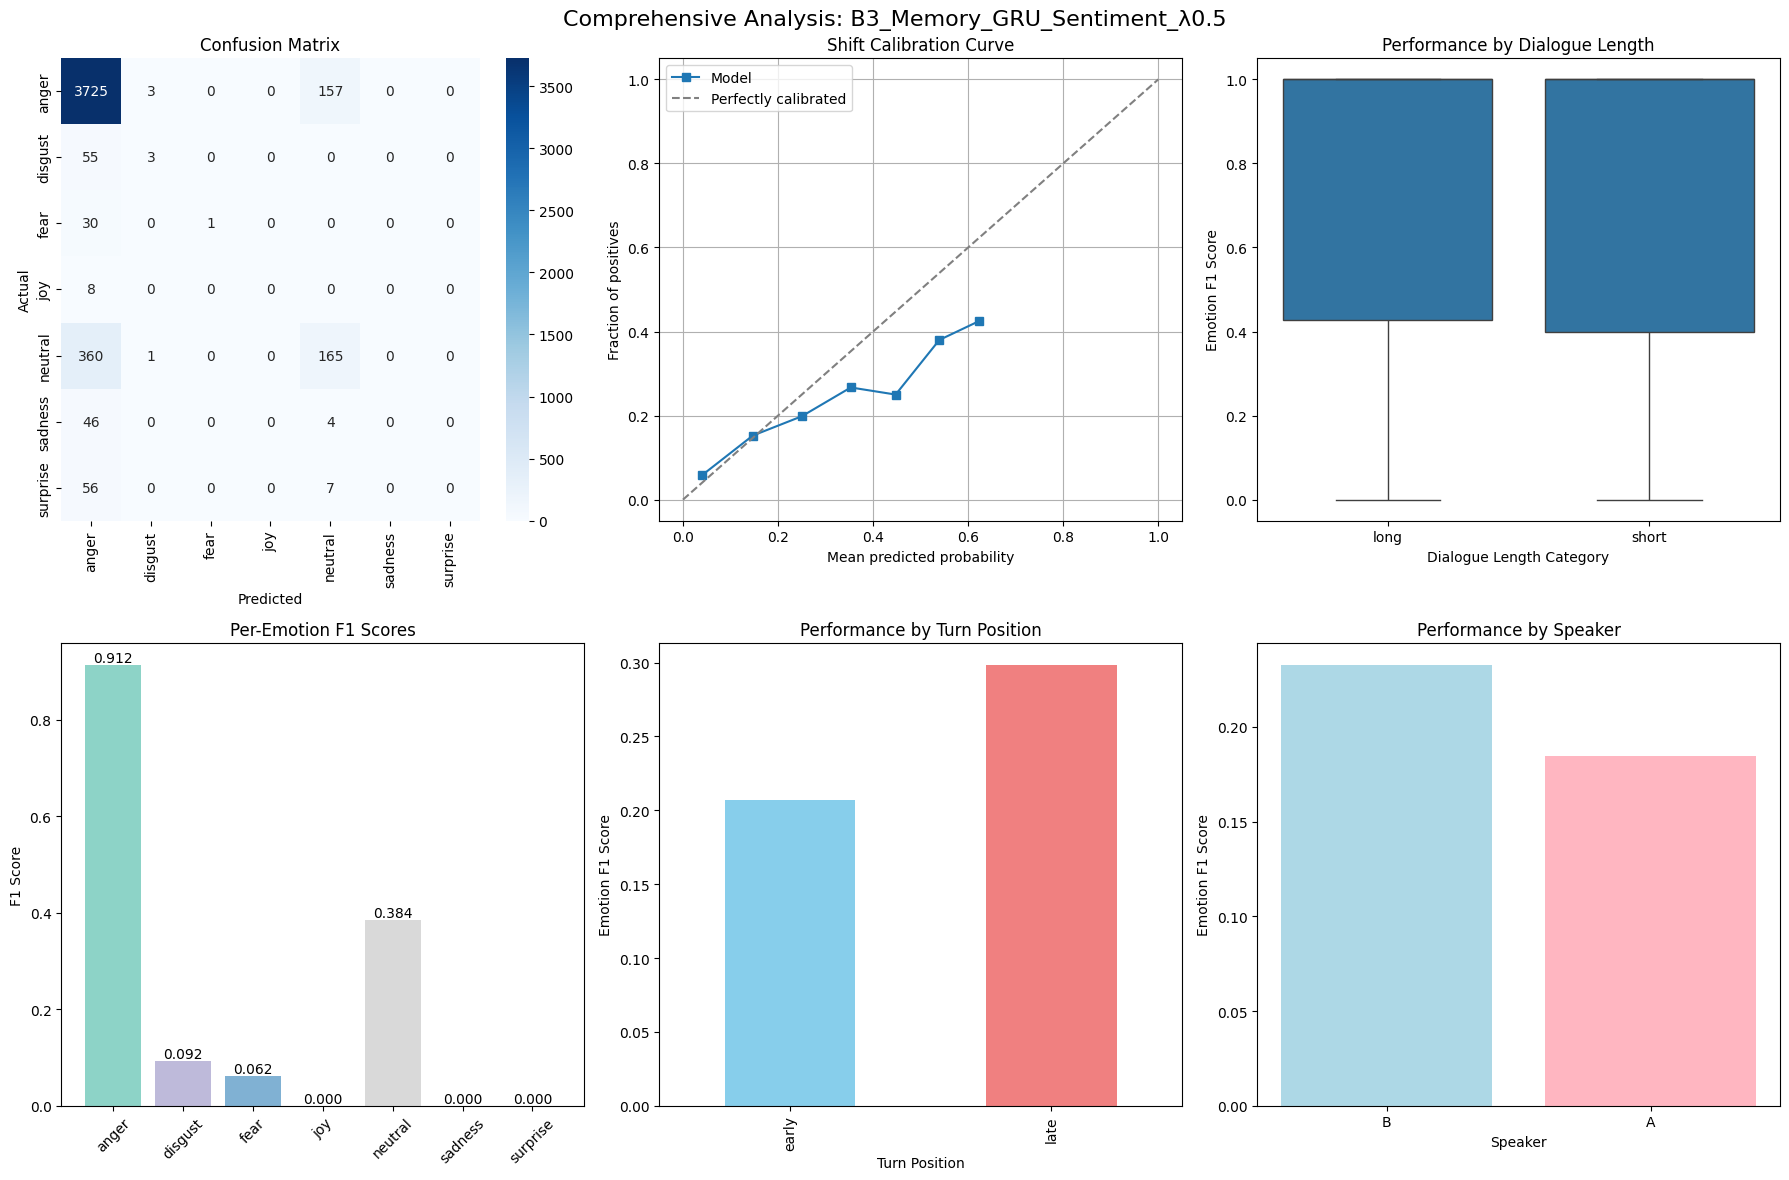

 Saving memory experiments...
✅ Memory analyzer saved to: /content/drive/MyDrive/emotion_experiments/results/memory_analyzer_20251023_051613.pkl
✅ Memory results table saved to: /content/drive/MyDrive/emotion_experiments/tables/memory_results_20251023_051613.csv
✅ B3_Memory_GRU_λ0.5 weights saved to: /content/drive/MyDrive/emotion_experiments/models/B3_Memory_GRU_λ0.5_weights_20251023_051613.pth
✅ B3_Memory_Gated_λ0.5 weights saved to: /content/drive/MyDrive/emotion_experiments/models/B3_Memory_Gated_λ0.5_weights_20251023_051613.pth
✅ B3_Memory_GRU_Trunc5_λ0.5 weights saved to: /content/drive/MyDrive/emotion_experiments/models/B3_Memory_GRU_Trunc5_λ0.5_weights_20251023_051613.pth
✅ B3_Memory_GRU_Sentiment_λ0.5 weights saved to: /content/drive/MyDrive/emotion_experiments/models/B3_Memory_GRU_Sentiment_λ0.5_weights_20251023_051613.pth
                          Model Emotion Macro-F1 Shift F1 Shift AUPRC  \
0            B3_Memory_GRU_λ0.5           0.1972   0.0937      0.3235   
1        

In [ ]:

train_loader_b3 = DataLoader(
    train_dataset, batch_size=8, shuffle=True,
    collate_fn=lambda x: collate_fn_b3(x, roberta_tokenizer)
)
val_loader_b3 = DataLoader(valid_dataset, batch_size=8, shuffle=False,
                          collate_fn=lambda x: collate_fn_b3(x, roberta_tokenizer))
test_loader_b3 = DataLoader(test_dataset, batch_size=8, shuffle=False,
                           collate_fn=lambda x: collate_fn_b3(x, roberta_tokenizer))


print("\n Starting Memory Experiments with Saving...")
memory_analyzer, memory_models, memory_path = run_memory_experiment_grid(
    train_loader_b3, val_loader_b3, test_loader_b3, device
)


final_table = memory_analyzer.create_comprehensive_ablation_table()
print(final_table)

In [ ]:

print("\n All Saved Experiments:")
saver.list_saved_experiments()


 All Saved Experiments:
📁 Saved Experiments:

Baseline Experiments:
  - baseline_analyzer_20251022_141539.pkl
  - baseline_analyzer_20251022_171115.pkl

Memory Experiments:
  - memory_analyzer_20251023_051613.pkl

Total: 2 baseline, 1 memory experiments


In [ ]:

final_table_path = os.path.join(saver.tables_dir, f"final_combined_results_{saver.timestamp}.csv")
final_table.to_csv(final_table_path, index=False)
print(f"Final combined results saved to: {final_table_path}")

✅ Final combined results saved to: /content/drive/MyDrive/emotion_experiments/tables/final_combined_results_20251023_051613.csv
